In [24]:
import numpy as numpy
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy as sp

In [25]:
df=pd.read_csv('crime.csv')
df.head()

,County,Agency,Year,Months Reported,Index Total,Violent Total,Murder,Rape,Robbery,Aggravated Assault,Property Total,Burglary,Larceny,Motor Vehicle Theft,Region
0,Albany,Albany City PD,2024,12.0,"4,057",985,13,90,233,649,"3,072",409,"2,360",303,Non-New York City
1,Albany,Albany County Park PD,2024,12.0,0,0,0,0,0,0,0,0,0,0,Non-New York City
2,Albany,Albany County Sheriff,2024,12.0,58,8,0,1,1,6,50,7,40,3,Non-New York City
3,Albany,Albany County State Police,2024,11.0,181,58,1,12,1,44,123,4,112,7,Non-New York City
4,Albany,Altamont Vg PD,2024,12.0,5,0,0,0,0,0,5,0,5,0,Non-New York City


In [26]:
#---------drop duplicates and check info---------
df=df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23832 entries, 0 to 23831
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   County               23832 non-null  object 
 1   Agency               23832 non-null  object 
 2   Year                 23832 non-null  int64  
 3   Months Reported      14136 non-null  float64
 4   Index Total          23832 non-null  object 
 5   Violent Total        23832 non-null  object 
 6   Murder               23832 non-null  int64  
 7   Rape                 23832 non-null  object 
 8   Robbery              23832 non-null  object 
 9   Aggravated Assault   23832 non-null  object 
 10  Property Total       23832 non-null  object 
 11  Burglary             23832 non-null  object 
 12  Larceny              23832 non-null  object 
 13  Motor Vehicle Theft  23832 non-null  object 
 14  Region               23832 non-null  object 
dtypes: float64(1), int64(2), object(12)


In [27]:
#---------convert crime columns to numeric---------
cols = [
    'Index Total','Violent Total', 'Rape', 'Robbery', 'Aggravated Assault',
    'Property Total', 'Burglary', 'Larceny', 'Motor Vehicle Theft'
]

df[cols] = df[cols].apply(lambda x: pd.to_numeric(x.astype(str).str.replace(',', ''), errors='coerce')).astype('Int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23832 entries, 0 to 23831
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   County               23832 non-null  object 
 1   Agency               23832 non-null  object 
 2   Year                 23832 non-null  int64  
 3   Months Reported      14136 non-null  float64
 4   Index Total          23832 non-null  Int64  
 5   Violent Total        23832 non-null  Int64  
 6   Murder               23832 non-null  int64  
 7   Rape                 23832 non-null  Int64  
 8   Robbery              23832 non-null  Int64  
 9   Aggravated Assault   23832 non-null  Int64  
 10  Property Total       23832 non-null  Int64  
 11  Burglary             23832 non-null  Int64  
 12  Larceny              23832 non-null  Int64  
 13  Motor Vehicle Theft  23832 non-null  Int64  
 14  Region               23832 non-null  object 
dtypes: Int64(9), float64(1), int64(2), o

In [28]:
#---------drop unnecessary columns---------
df_filtered = df.drop(["Months Reported",'Region'], axis=1)

df_filtered.head()

,County,Agency,Year,Index Total,Violent Total,Murder,Rape,Robbery,Aggravated Assault,Property Total,Burglary,Larceny,Motor Vehicle Theft
0,Albany,Albany City PD,2024,4057,985,13,90,233,649,3072,409,2360,303
1,Albany,Albany County Park PD,2024,0,0,0,0,0,0,0,0,0,0
2,Albany,Albany County Sheriff,2024,58,8,0,1,1,6,50,7,40,3
3,Albany,Albany County State Police,2024,181,58,1,12,1,44,123,4,112,7
4,Albany,Altamont Vg PD,2024,5,0,0,0,0,0,5,0,5,0


In [29]:
#---------group by County and Year and sum crime counts---------
grouped_df = df.groupby(["County", "Year"], as_index=False).agg({
    "Index Total": "sum",
    "Violent Total": "sum",
    "Murder": "sum",
    "Rape": "sum",
    "Robbery": "sum",
    "Aggravated Assault": "sum",
    "Property Total": "sum",
    "Burglary": "sum",
    "Larceny": "sum",
    "Motor Vehicle Theft": "sum",
})
grouped_df.head()

,County,Year,Index Total,Violent Total,Murder,Rape,Robbery,Aggravated Assault,Property Total,Burglary,Larceny,Motor Vehicle Theft
0,Albany,1990,28374,3043,24,237,899,1883,25331,6311,17608,1412
1,Albany,1991,30434,3338,26,180,1162,1970,27096,6527,19074,1495
2,Albany,1992,31920,3157,22,192,1107,1836,28763,6880,20289,1594
3,Albany,1993,29718,3316,16,160,1105,2035,26402,6441,18622,1339
4,Albany,1994,32860,3520,26,202,1284,2008,29340,6782,20951,1607


In [30]:
grouped_df.to_csv("grouped_df.csv", index=False)

In [31]:
#---------clean population data---------
pop = pd.read_csv("Population.csv")
pop = pop.rename(columns={"Geography": "County"})
pop = pop[pop["County"].str.strip() != "New York State"].copy()
pop["County"] = (
    pop["County"]
    .astype(str)
    .str.replace(" County", "", regex=False)
    .str.strip()
)
print(pop.head())
pop.to_csv("population_final.csv", index=False)

   FIPS Code       County  Year                    Program Type Population
1      36001       Albany  2025  Postcensal Population Estimate    321,225
2      36003     Allegany  2025  Postcensal Population Estimate     46,800
3      36005        Bronx  2025  Postcensal Population Estimate  1,406,332
4      36007       Broome  2025  Postcensal Population Estimate    195,736
5      36009  Cattaraugus  2025  Postcensal Population Estimate     75,390


In [32]:
#---------clean population data (updated)---------
pop = pd.read_csv("Population_final.csv")
pop = pop.rename(columns={"geography": "County"})
pop["County"] = pop["County"].astype(str).str.strip()
pop = pop[pop["County"] != "New York State"].copy()
pop["County"] = pop["County"].str.replace(r"\s*County\s*$", "", regex=True).str.strip()
pop = pop[~pop["Year"].between(1970, 1989)]
pop = pop[pop["Year"] != 2025]
pop["County"] = pop["County"].replace("St. Lawrence", "St Lawrence")
pop = pop.drop(columns=["FIPS code"], errors="ignore")
print(pop.head())
pop.to_csv("population_final.csv", index=False)

    FIPS Code       County  Year                    Program Type Population
62      36001       Albany  2024  Postcensal Population Estimate    319,702
63      36003     Allegany  2024  Postcensal Population Estimate     46,822
64      36005        Bronx  2024  Postcensal Population Estimate  1,406,052
65      36007       Broome  2024  Postcensal Population Estimate    195,893
66      36009  Cattaraugus  2024  Postcensal Population Estimate     75,448


In [33]:
print(pop.columns.tolist())

['FIPS Code', 'County', 'Year', 'Program Type', 'Population']


In [34]:
pop = pop.drop(columns=["FIPS Code"])
print(pop.head())


         County  Year                    Program Type Population
62       Albany  2024  Postcensal Population Estimate    319,702
63     Allegany  2024  Postcensal Population Estimate     46,822
64        Bronx  2024  Postcensal Population Estimate  1,406,052
65       Broome  2024  Postcensal Population Estimate    195,893
66  Cattaraugus  2024  Postcensal Population Estimate     75,448


In [35]:
pop.head()

,County,Year,Program Type,Population
62,Albany,2024,Postcensal Population Estimate,"319,702"
63,Allegany,2024,Postcensal Population Estimate,"46,822"
64,Bronx,2024,Postcensal Population Estimate,"1,406,052"
65,Broome,2024,Postcensal Population Estimate,"195,893"
66,Cattaraugus,2024,Postcensal Population Estimate,"75,448"


In [36]:
pop.to_csv("population_final.csv", index=False)

In [ ]:
#---------filter for Intercensal Population Estimate rows---------
intercensal_rows = pop[pop["Program Type"] == "Intercensal Population Estimate"][["County", "Year", "Program Type", "Population"]].copy()

print(intercensal_rows)

           County  Year                     Program Type Population
434        Albany  2019  Intercensal Population Estimate    314,630
435      Allegany  2019  Intercensal Population Estimate     46,613
436         Bronx  2019  Intercensal Population Estimate  1,479,222
437        Broome  2019  Intercensal Population Estimate    198,864
438   Cattaraugus  2019  Intercensal Population Estimate     77,184
...           ...   ...                              ...        ...
2475   Washington  1990  Intercensal Population Estimate     59,507
2476        Wayne  1990  Intercensal Population Estimate     89,365
2477  Westchester  1990  Intercensal Population Estimate    875,578
2478      Wyoming  1990  Intercensal Population Estimate     42,563
2479        Yates  1990  Intercensal Population Estimate     22,891

[1860 rows x 4 columns]


In [40]:
#---------filter for both Intercensal and Postcensal Population Estimate rows and drop duplicates---------
wanted_types = [
    "Intercensal Population Estimate",
    "Postcensal Population Estimate"
]
pop = pop[pop["Program Type"].isin(wanted_types)].copy()
priority_map = {
    "Intercensal Population Estimate": 0,
    "Postcensal Population Estimate": 1
}
pop["priority"] = pop["Program Type"].map(priority_map)
pop = pop.sort_values(["County", "Year", "priority"])
pop = pop.drop_duplicates(subset=["County", "Year"], keep="first")
pop = pop.drop(columns=["priority"])
print(pop.head())


      County  Year                     Program Type Population
2418  Albany  1990  Intercensal Population Estimate    292,956
2294  Albany  1991  Intercensal Population Estimate    295,530
2232  Albany  1992  Intercensal Population Estimate    296,913
2170  Albany  1993  Intercensal Population Estimate    298,592
2108  Albany  1994  Intercensal Population Estimate    300,262


In [41]:
pop.to_csv("population_final.csv", index=False)

In [42]:
pop = pop.drop(columns=["Program Type"])

In [43]:
print(pop.head())

      County  Year Population
2418  Albany  1990    292,956
2294  Albany  1991    295,530
2232  Albany  1992    296,913
2170  Albany  1993    298,592
2108  Albany  1994    300,262


In [44]:
pop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2170 entries, 2418 to 123
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   County      2170 non-null   object
 1   Year        2170 non-null   int64 
 2   Population  2170 non-null   object
dtypes: int64(1), object(2)
memory usage: 67.8+ KB


In [45]:
pop.to_csv("population_final.csv", index=False)

In [46]:
#---------merge crime and population data---------
crime = pd.read_csv("grouped_df.csv")
population = pd.read_csv("population_final.csv")
crime["County"] = crime["County"].astype(str).str.strip()
population["County"] = population["County"].astype(str).str.strip()

crime["Year"] = pd.to_numeric(crime["Year"], errors="coerce")
population["Year"] = pd.to_numeric(population["Year"], errors="coerce")
merged_df = crime.merge(
    population,
    on=["County", "Year"],
    how="left" 
)

# Save file
merged_df.to_csv("crime_with_population.csv", index=False)

print(merged_df.head())
print(merged_df.shape)

   County  Year  Index Total  Violent Total  Murder  Rape  Robbery  \
0  Albany  1990        28374           3043      24   237      899   
1  Albany  1991        30434           3338      26   180     1162   
2  Albany  1992        31920           3157      22   192     1107   
3  Albany  1993        29718           3316      16   160     1105   
4  Albany  1994        32860           3520      26   202     1284   

   Aggravated Assault  Property Total  Burglary  Larceny  Motor Vehicle Theft  \
0                1883           25331      6311    17608                 1412   
1                1970           27096      6527    19074                 1495   
2                1836           28763      6880    20289                 1594   
3                2035           26402      6441    18622                 1339   
4                2008           29340      6782    20951                 1607   

  Population  
0    292,956  
1    295,530  
2    296,913  
3    298,592  
4    300,262  
(2

In [47]:
print(merged_df["Population"].isna().sum())

0


In [48]:
#---------calculate crime rates per 100,000 population---------
merged_df["Population"] = (
    merged_df["Population"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
merged_df["Population"] = pd.to_numeric(merged_df["Population"], errors="coerce")

rate_cols = [
    "Index Total", "Property Total", "Violent Total", "Murder", "Rape",
    "Robbery", "Aggravated Assault", "Burglary", "Larceny", "Motor Vehicle Theft"
]
for col in rate_cols:
    merged_df[col.replace(" ", "_") + "_Rate"] = (merged_df[col] / merged_df["Population"]) * 100000

In [50]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2170 entries, 0 to 2169
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   County                    2170 non-null   object 
 1   Year                      2170 non-null   int64  
 2   Index Total               2170 non-null   int64  
 3   Violent Total             2170 non-null   int64  
 4   Murder                    2170 non-null   int64  
 5   Rape                      2170 non-null   int64  
 6   Robbery                   2170 non-null   int64  
 7   Aggravated Assault        2170 non-null   int64  
 8   Property Total            2170 non-null   int64  
 9   Burglary                  2170 non-null   int64  
 10  Larceny                   2170 non-null   int64  
 11  Motor Vehicle Theft       2170 non-null   int64  
 12  Population                2170 non-null   int64  
 13  Index_Total_Rate          2170 non-null   float64
 14  Property

In [51]:
merged_df.to_csv("merged_final.csv", index=False)

In [52]:
merged_df.columns

Index(['County', 'Year', 'Index Total', 'Violent Total', 'Murder', 'Rape',
       'Robbery', 'Aggravated Assault', 'Property Total', 'Burglary',
       'Larceny', 'Motor Vehicle Theft', 'Population', 'Index_Total_Rate',
       'Property_Total_Rate', 'Violent_Total_Rate', 'Murder_Rate', 'Rape_Rate',
       'Robbery_Rate', 'Aggravated_Assault_Rate', 'Burglary_Rate',
       'Larceny_Rate', 'Motor_Vehicle_Theft_Rate'],
      dtype='object')

In [53]:
merged_df.head()

,County,Year,Index Total,Violent Total,Murder,Rape,Robbery,Aggravated Assault,Property Total,Burglary,...,Index_Total_Rate,Property_Total_Rate,Violent_Total_Rate,Murder_Rate,Rape_Rate,Robbery_Rate,Aggravated_Assault_Rate,Burglary_Rate,Larceny_Rate,Motor_Vehicle_Theft_Rate
0,Albany,1990,28374,3043,24,237,899,1883,25331,6311,...,9685.413509,8646.690971,1038.722539,8.192357,80.899521,306.872022,642.758640,2154.248420,6010.458909,481.983643
1,Albany,1991,30434,3338,26,180,1162,1970,27096,6527,...,10298.108483,9168.612324,1129.496159,8.797753,60.907522,393.191893,666.598992,2208.574426,6454.167090,505.870808
2,Albany,1992,31920,3157,22,192,1107,1836,28763,6880,...,10750.623920,9687.349493,1063.274427,7.409578,64.665407,372.836487,618.362955,2317.177086,6833.314809,536.857598
3,Albany,1993,29718,3316,16,160,1105,2035,26402,6441,...,9952.711392,8842.165899,1110.545494,5.358482,53.584825,370.070196,681.531990,2157.124102,6236.603794,448.438002
4,Albany,1994,32860,3520,26,202,1284,2008,29340,6782,...,10943.775769,9771.466253,1172.309516,8.659104,67.274580,427.626539,668.749292,2258.694074,6977.572920,535.199259


In [54]:

merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2170 entries, 0 to 2169
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   County                    2170 non-null   object 
 1   Year                      2170 non-null   int64  
 2   Index Total               2170 non-null   int64  
 3   Violent Total             2170 non-null   int64  
 4   Murder                    2170 non-null   int64  
 5   Rape                      2170 non-null   int64  
 6   Robbery                   2170 non-null   int64  
 7   Aggravated Assault        2170 non-null   int64  
 8   Property Total            2170 non-null   int64  
 9   Burglary                  2170 non-null   int64  
 10  Larceny                   2170 non-null   int64  
 11  Motor Vehicle Theft       2170 non-null   int64  
 12  Population                2170 non-null   int64  
 13  Index_Total_Rate          2170 non-null   float64
 14  Property

In [ ]:
#---------round crime rates to 2 decimal places---------
rate_cols = [col for col in merged_df.columns if "Rate" in col]
merged_df[rate_cols] = merged_df[rate_cols].round(2)

In [56]:
merged_df.head()

,County,Year,Index Total,Violent Total,Murder,Rape,Robbery,Aggravated Assault,Property Total,Burglary,...,Index_Total_Rate,Property_Total_Rate,Violent_Total_Rate,Murder_Rate,Rape_Rate,Robbery_Rate,Aggravated_Assault_Rate,Burglary_Rate,Larceny_Rate,Motor_Vehicle_Theft_Rate
0,Albany,1990,28374,3043,24,237,899,1883,25331,6311,...,9685.41,8646.69,1038.72,8.19,80.90,306.87,642.76,2154.25,6010.46,481.98
1,Albany,1991,30434,3338,26,180,1162,1970,27096,6527,...,10298.11,9168.61,1129.50,8.80,60.91,393.19,666.60,2208.57,6454.17,505.87
2,Albany,1992,31920,3157,22,192,1107,1836,28763,6880,...,10750.62,9687.35,1063.27,7.41,64.67,372.84,618.36,2317.18,6833.31,536.86
3,Albany,1993,29718,3316,16,160,1105,2035,26402,6441,...,9952.71,8842.17,1110.55,5.36,53.58,370.07,681.53,2157.12,6236.60,448.44
4,Albany,1994,32860,3520,26,202,1284,2008,29340,6782,...,10943.78,9771.47,1172.31,8.66,67.27,427.63,668.75,2258.69,6977.57,535.20


In [57]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2170 entries, 0 to 2169
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   County                    2170 non-null   object 
 1   Year                      2170 non-null   int64  
 2   Index Total               2170 non-null   int64  
 3   Violent Total             2170 non-null   int64  
 4   Murder                    2170 non-null   int64  
 5   Rape                      2170 non-null   int64  
 6   Robbery                   2170 non-null   int64  
 7   Aggravated Assault        2170 non-null   int64  
 8   Property Total            2170 non-null   int64  
 9   Burglary                  2170 non-null   int64  
 10  Larceny                   2170 non-null   int64  
 11  Motor Vehicle Theft       2170 non-null   int64  
 12  Population                2170 non-null   int64  
 13  Index_Total_Rate          2170 non-null   float64
 14  Property

In [58]:
merged_df.to_csv("crime_with_population_rates.csv", index=False)

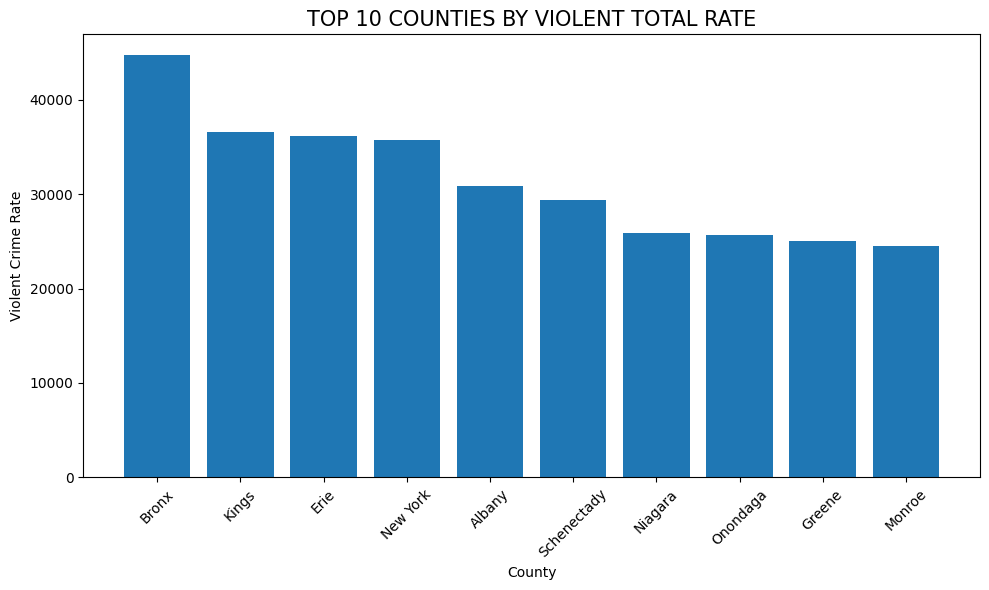

In [ ]:
#---------plot top 10 counties by Violent Total Rate---------
df = pd.read_csv("crime_with_population_rates.csv")
top10_counties = (
    df.groupby("County", as_index=False)["Violent_Total_Rate"]
    .sum()
    .sort_values("Violent_Total_Rate", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.bar(top10_counties["County"], top10_counties["Violent_Total_Rate"])
plt.xticks(rotation=45)
plt.xlabel("County")
plt.ylabel("Violent Crime Rate")
plt.title("TOP 10 COUNTIES BY VIOLENT TOTAL RATE", fontsize = 15)
plt.tight_layout()
plt.show()

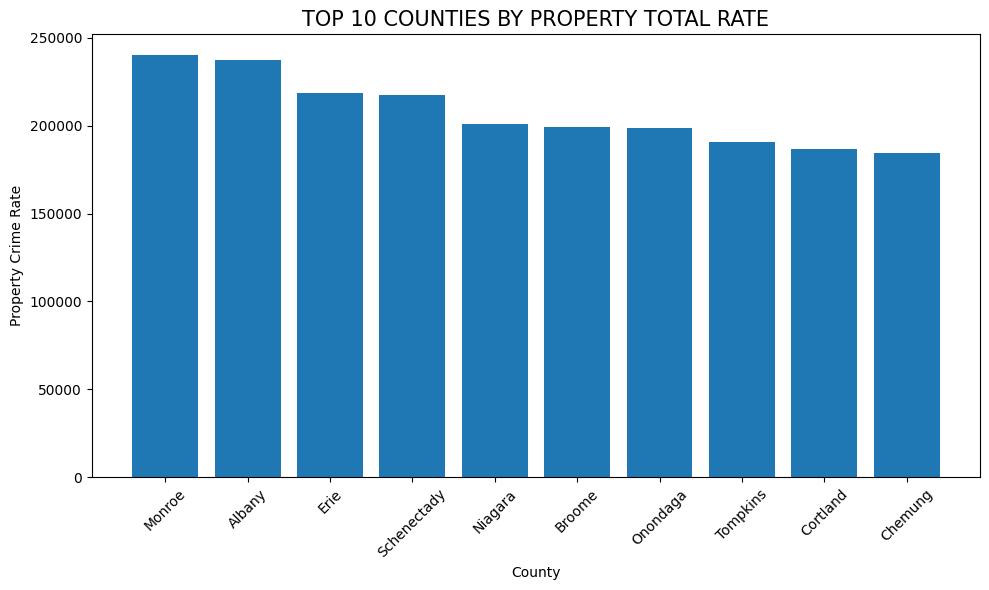

In [60]:
#---------plot top 10 counties by Property Total Rate---------
top10_counties = (
    df.groupby("County", as_index=False)["Property_Total_Rate"]
    .sum()
    .sort_values("Property_Total_Rate", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.bar(top10_counties["County"], top10_counties["Property_Total_Rate"])
plt.xticks(rotation=45)
plt.xlabel("County")
plt.ylabel("Property Crime Rate")
plt.title("TOP 10 COUNTIES BY PROPERTY TOTAL RATE", fontsize = 15)
plt.tight_layout()
plt.show()

      Year       County  Index_Total_Rate
1050  1990     New York          14645.28
1051  1991     New York          14098.87
1052  1992     New York          12648.89
948   1993       Monroe          11564.26
4     1994       Albany          10943.78
5     1995       Albany          10960.05
951   1996       Monroe          10299.39
952   1997       Monroe           9983.47
953   1998       Monroe           9380.50
9     1999       Albany           9599.85
10    2000       Albany           9553.18
11    2001       Albany           9271.79
12    2002       Albany           8571.73
958   2003       Monroe           8545.03
14    2004       Albany           8412.40
15    2005       Albany           8004.86
1591  2006  Schenectady           8150.60
507   2007         Erie           7213.25
1593  2008  Schenectady           7359.15
1594  2009  Schenectady           7568.97
1595  2010  Schenectady           7772.49
1596  2011  Schenectady           7124.77
1597  2012  Schenectady           

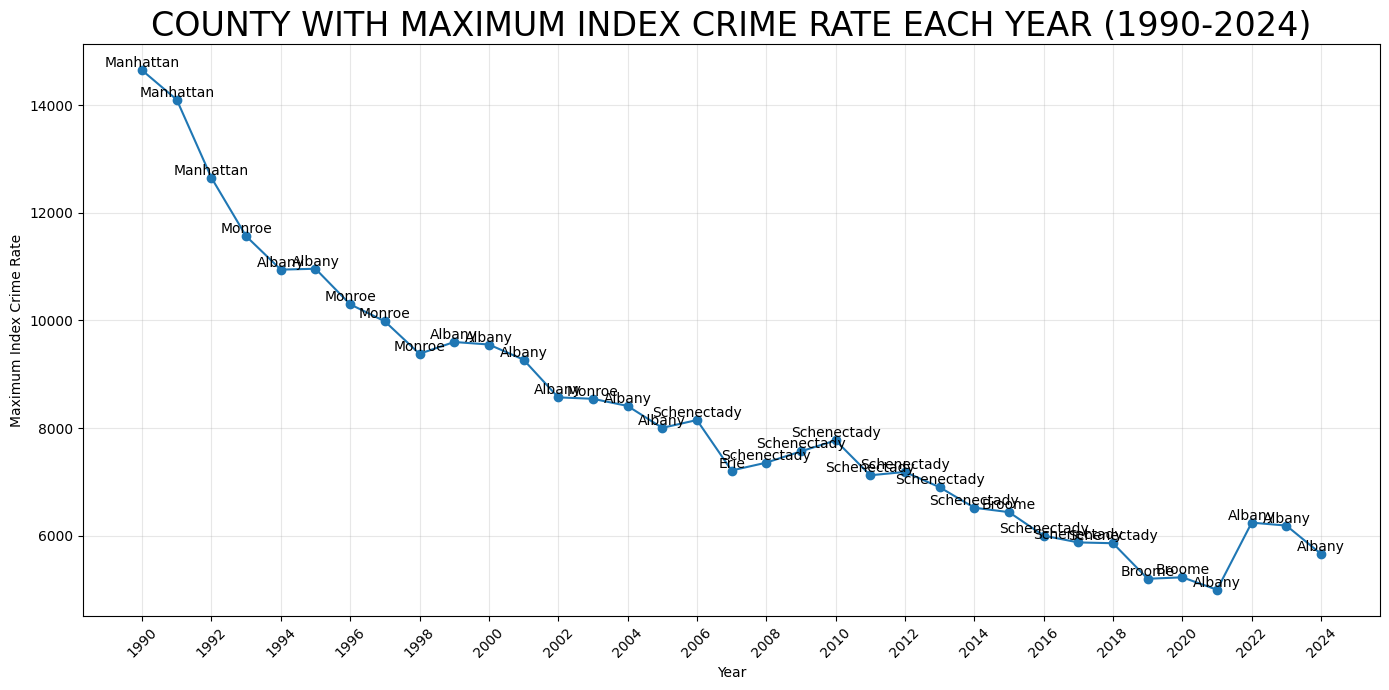

In [64]:
#---------plot county with maximum Index Total Rate each year---------
df = pd.read_csv("crime_with_population_rates.csv")
df = df[(df["Year"] >= 1990) & (df["Year"] <= 2024)].copy()
df = df.dropna(subset=["County", "Year", "Index_Total_Rate"])
max_rate_each_year = df.loc[df.groupby("Year")["Index_Total_Rate"].idxmax()].copy()
max_rate_each_year = max_rate_each_year.sort_values("Year")
print(max_rate_each_year[["Year", "County", "Index_Total_Rate"]])
plt.figure(figsize=(14, 7))
plt.plot(max_rate_each_year["Year"], max_rate_each_year["Index_Total_Rate"], marker="o")
for _, row in max_rate_each_year.iterrows():
    county_name = "Manhattan" if row["County"] == "New York" else row["County"]
    plt.text(
        row["Year"],
        row["Index_Total_Rate"],
        county_name,
        fontsize=10,
        ha="center",
        va="bottom"
    )

plt.title("COUNTY WITH MAXIMUM INDEX CRIME RATE EACH YEAR (1990-2024)", fontsize=24)
plt.xlabel("Year")
plt.ylabel("Maximum Index Crime Rate")
plt.xticks(range(1990, 2025, 2), rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for violent crime

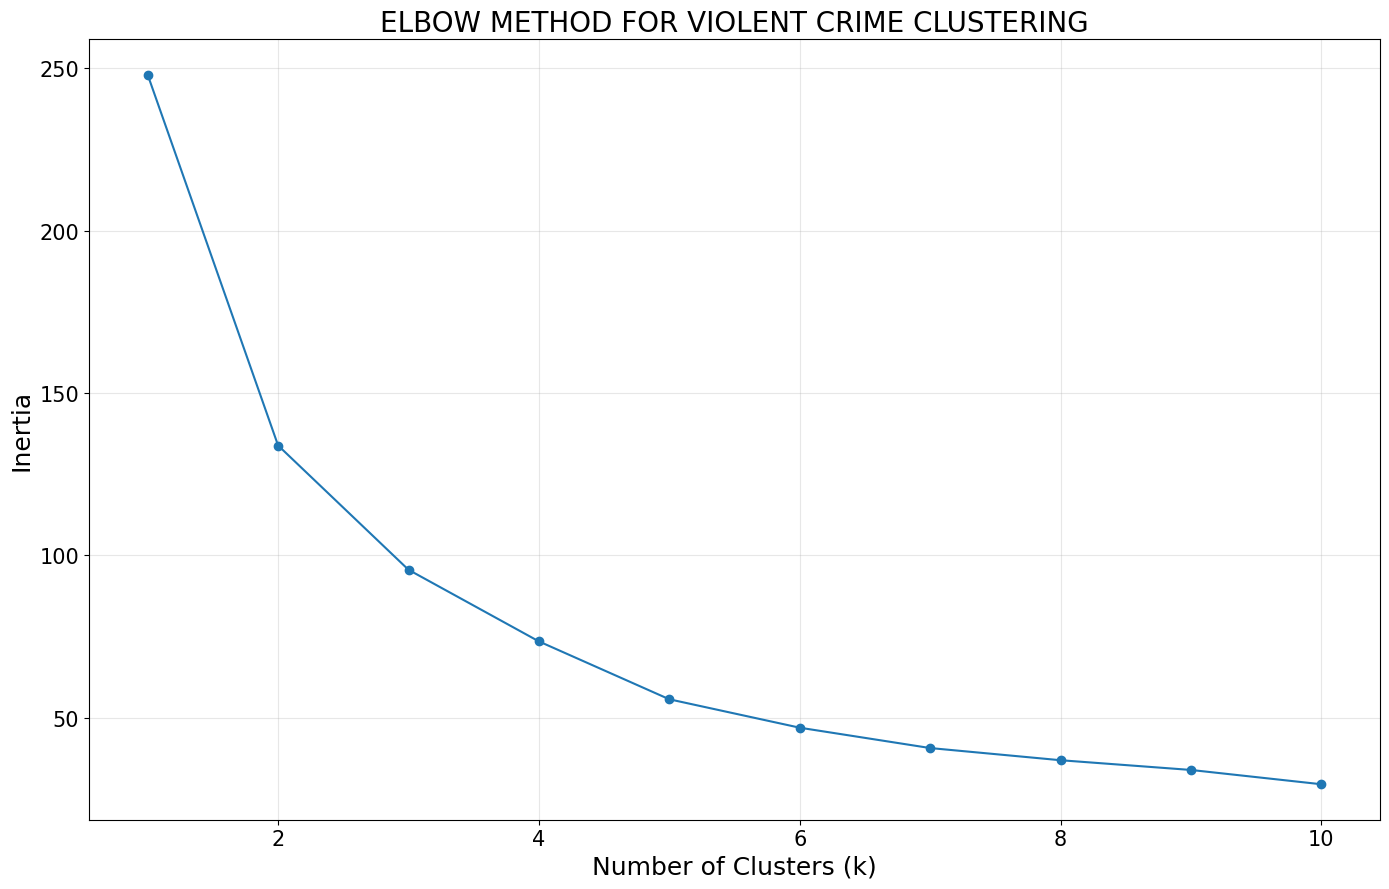


Violent Crime Cluster 0
['Bronx', 'Erie', 'Kings', 'Monroe', 'New York']

Violent Crime Cluster 1
['Allegany', 'Broome', 'Cattaraugus', 'Cayuga', 'Chautauqua', 'Chenango', 'Clinton', 'Columbia', 'Cortland', 'Delaware', 'Essex', 'Franklin', 'Fulton', 'Genesee', 'Hamilton', 'Herkimer', 'Jefferson', 'Lewis', 'Livingston', 'Madison', 'Montgomery', 'Ontario', 'Orleans', 'Oswego', 'Otsego', 'Saratoga', 'Schoharie', 'Schuyler', 'Seneca', 'St Lawrence', 'Steuben', 'Tioga', 'Tompkins', 'Ulster', 'Warren', 'Washington', 'Wayne', 'Wyoming', 'Yates']

Violent Crime Cluster 2
['Albany', 'Chemung', 'Dutchess', 'Greene', 'Niagara', 'Oneida', 'Onondaga', 'Orange', 'Rensselaer', 'Schenectady', 'Sullivan']

Violent Crime Cluster 3
['Nassau', 'Putnam', 'Queens', 'Richmond', 'Rockland', 'Suffolk', 'Westchester']

Violent Crime Cluster Summary
                 Murder_Rate  Rape_Rate  Robbery_Rate  Aggravated_Assault_Rate
Violent_Cluster                                                               
0     

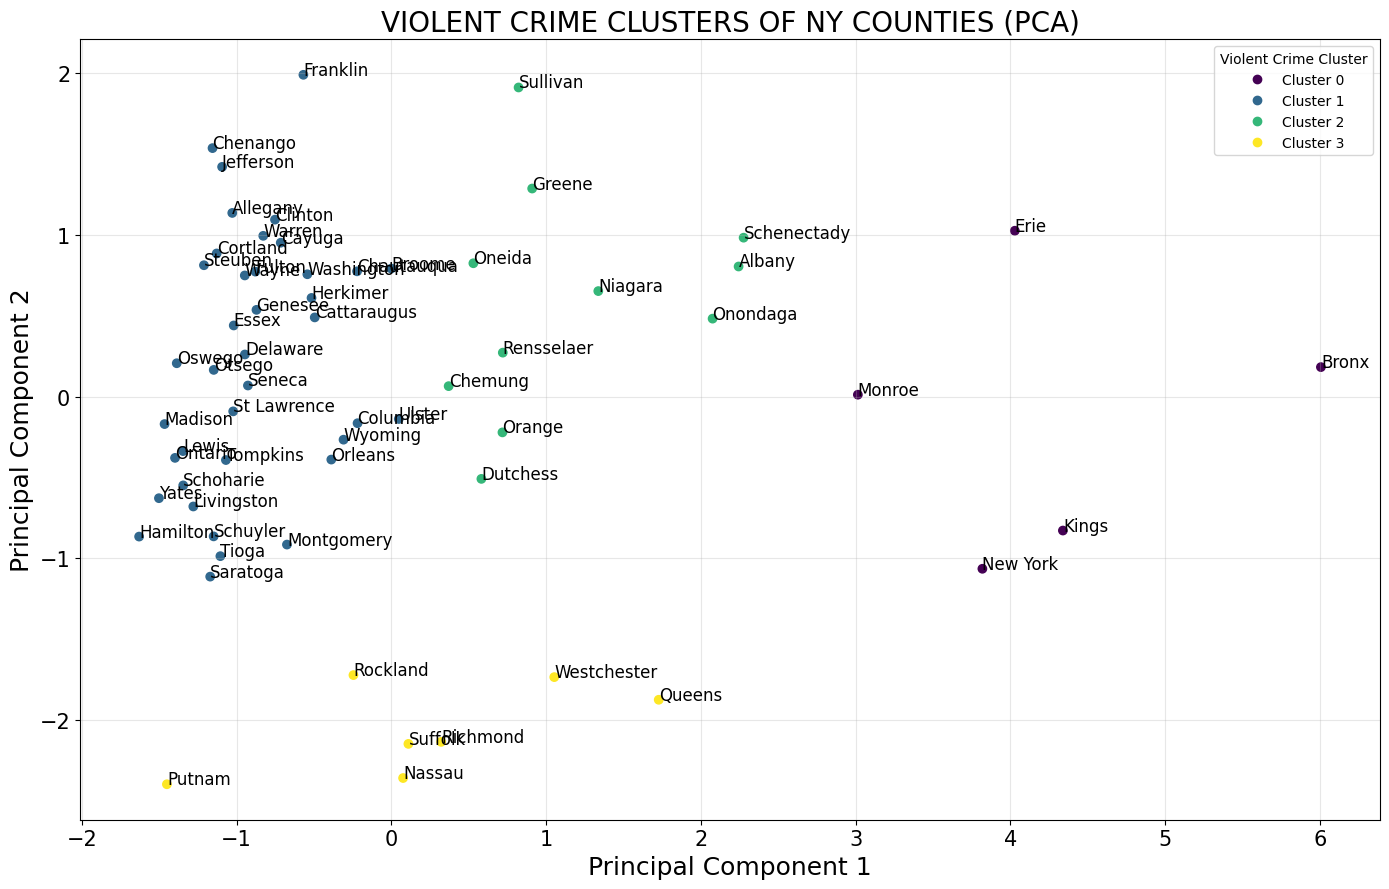

In [68]:
#---------KMeans Clustering on Violent Crime Rates---------
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
df = pd.read_csv("crime_with_population_rates.csv")

violent_df = (
    df.groupby("County", as_index=False)[
        ["Murder_Rate", "Rape_Rate", "Robbery_Rate", "Aggravated_Assault_Rate"]
    ]
    .mean()
)

violent_df = violent_df.dropna()
counties = violent_df["County"]
X_violent = violent_df.drop("County", axis=1)
scaler = StandardScaler()
X_violent_scaled = scaler.fit_transform(X_violent)


# Elbow Method

inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_violent_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(14, 9))
plt.plot(range(1, 11), inertia, marker="o")
plt.title("ELBOW METHOD FOR VIOLENT CRIME CLUSTERING", fontsize = 20)
plt.xlabel("Number of Clusters (k)", fontsize = 18)
plt.ylabel("Inertia", fontsize = 18)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
violent_df["Violent_Cluster"] = kmeans.fit_predict(X_violent_scaled)
for cluster in sorted(violent_df["Violent_Cluster"].unique()):
    print(f"\nViolent Crime Cluster {cluster}")
    print(violent_df[violent_df["Violent_Cluster"] == cluster]["County"].tolist())


# Cluster Summary

violent_summary = (
    violent_df.groupby("Violent_Cluster")[
        ["Murder_Rate", "Rape_Rate", "Robbery_Rate", "Aggravated_Assault_Rate"]
    ]
    .mean()
    .round(2)
)

print("\nViolent Crime Cluster Summary")
print(violent_summary)

# PCA for Visualization

pca = PCA(n_components=2)
violent_pca = pca.fit_transform(X_violent_scaled)

violent_df["PC1"] = violent_pca[:, 0]
violent_df["PC2"] = violent_pca[:, 1]

plt.figure(figsize=(14, 9))
scatter = plt.scatter(
    violent_df["PC1"],
    violent_df["PC2"],
    c=violent_df["Violent_Cluster"]
)

for _, row in violent_df.iterrows():
    plt.text(row["PC1"], row["PC2"], row["County"], fontsize=12)

handles, _ = scatter.legend_elements()
labels = [f"Cluster {i}" for i in sorted(violent_df["Violent_Cluster"].unique())]
plt.legend(handles, labels, title="Violent Crime Cluster")


plt.title("VIOLENT CRIME CLUSTERS OF NY COUNTIES (PCA)", fontsize = 20)
plt.xlabel("Principal Component 1", fontsize = 18)
plt.ylabel("Principal Component 2", fontsize = 18)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# PCA for Visualization
pca = PCA(n_components=2)
violent_pca = pca.fit_transform(X_violent_scaled)

violent_df["PC1"] = violent_pca[:, 0]
violent_df["PC2"] = violent_pca[:, 1]

# Explained variance
print("Explained variance ratio (Violent Crime PCA):")
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

Explained variance ratio (Violent Crime PCA):
PC1: 0.6437
PC2: 0.2675
Total explained variance: 0.9112


In [70]:
pca = PCA(n_components=2)
violent_pca = pca.fit_transform(X_violent_scaled)
# PCA loadings for violent crime
loadings_violent = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X_violent.columns
)

print("Violent Crime PCA Loadings:")
print(loadings_violent.round(4))

Violent Crime PCA Loadings:
                            PC1     PC2
Murder_Rate              0.5871  0.1060
Rape_Rate               -0.2088  0.8932
Robbery_Rate             0.5955 -0.1429
Aggravated_Assault_Rate  0.5070  0.4129


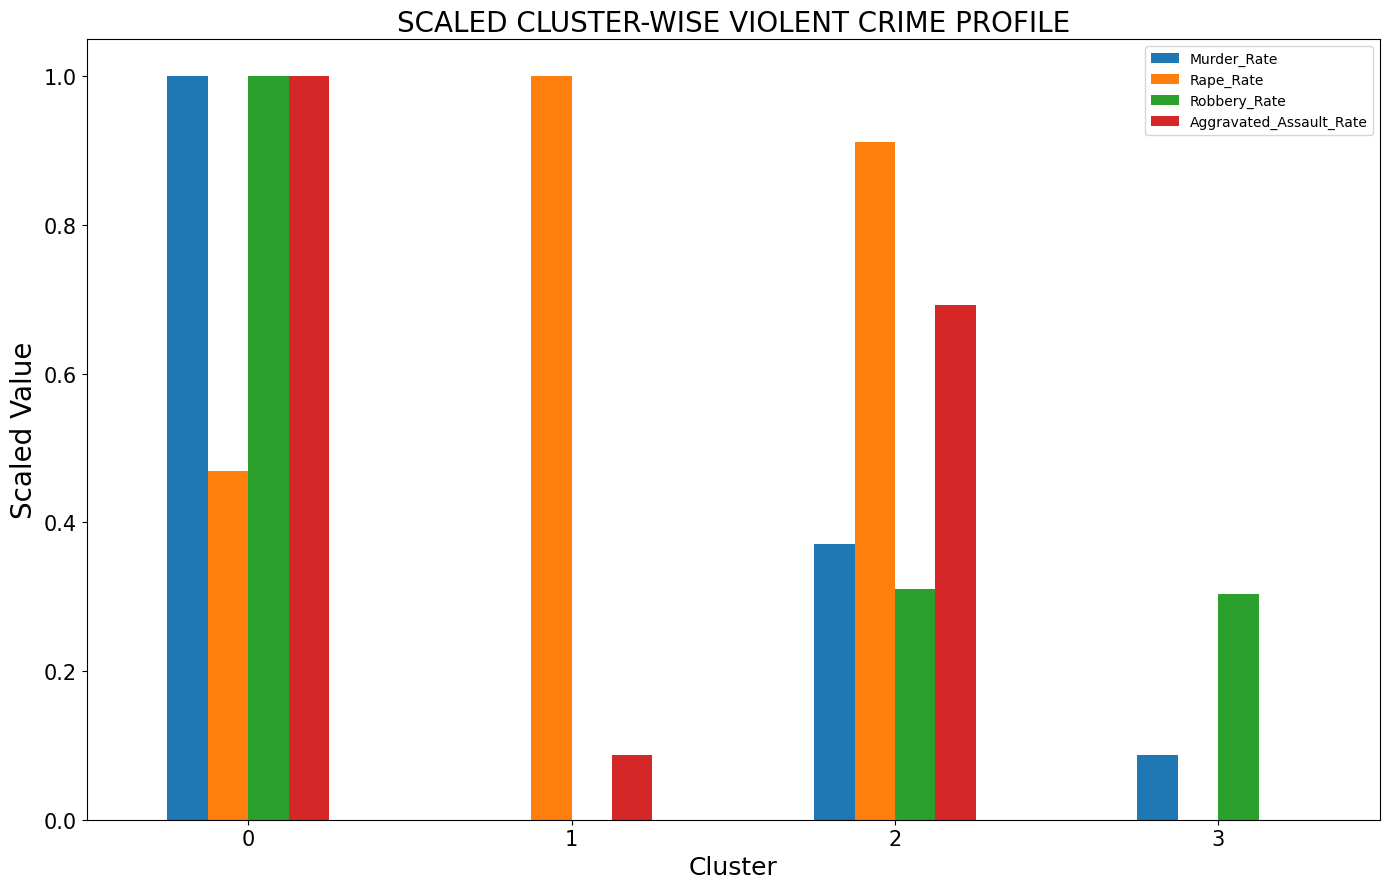

In [71]:
# Cluster-wise mean profile using original rate values
from sklearn.preprocessing import MinMaxScaler
df = pd.read_csv("crime_with_population_rates.csv")

violent_df = (
    df.groupby("County", as_index=False)[
        ["Murder_Rate", "Rape_Rate", "Robbery_Rate", "Aggravated_Assault_Rate"]
    ]
    .mean()
    .dropna()
)

X_violent = violent_df.drop("County", axis=1)

scaler = StandardScaler()
X_violent_scaled = scaler.fit_transform(X_violent)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
violent_df["Violent_Cluster"] = kmeans.fit_predict(X_violent_scaled)
violent_profile = (
    violent_df.groupby("Violent_Cluster")[
        ["Murder_Rate", "Rape_Rate", "Robbery_Rate", "Aggravated_Assault_Rate"]
    ]
    .mean()
)

minmax = MinMaxScaler()
violent_profile_scaled = pd.DataFrame(
    minmax.fit_transform(violent_profile),
    columns=violent_profile.columns,
    index=violent_profile.index
)

violent_profile_scaled.plot(kind="bar", figsize=(14, 9))
plt.title("SCALED CLUSTER-WISE VIOLENT CRIME PROFILE", fontsize=20)
plt.xlabel("Cluster", fontsize=18)
plt.ylabel("Scaled Value", fontsize=20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

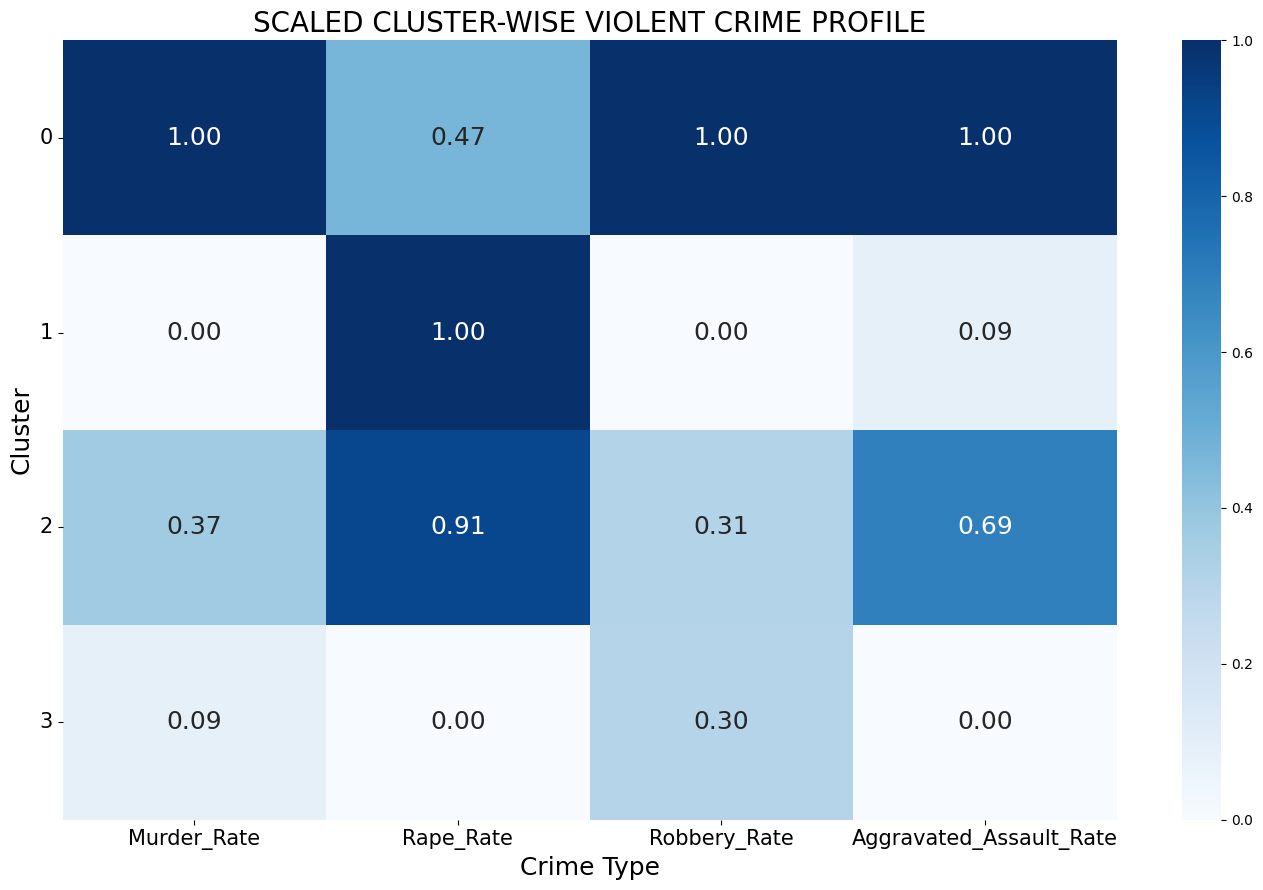

In [72]:
# Heatmap of scaled cluster-wise violent crime profiles
plt.figure(figsize=(14, 9))
sns.heatmap(violent_profile_scaled, annot=True, cmap="Blues", fmt=".2f", annot_kws={"size": 18} )

plt.title("SCALED CLUSTER-WISE VIOLENT CRIME PROFILE", fontsize=20)
plt.xlabel("Crime Type", fontsize=18)
plt.ylabel("Cluster", fontsize=18)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

plt.xticks(rotation=0)  
plt.yticks(rotation=0)   

plt.tight_layout()
plt.show()

for property crime

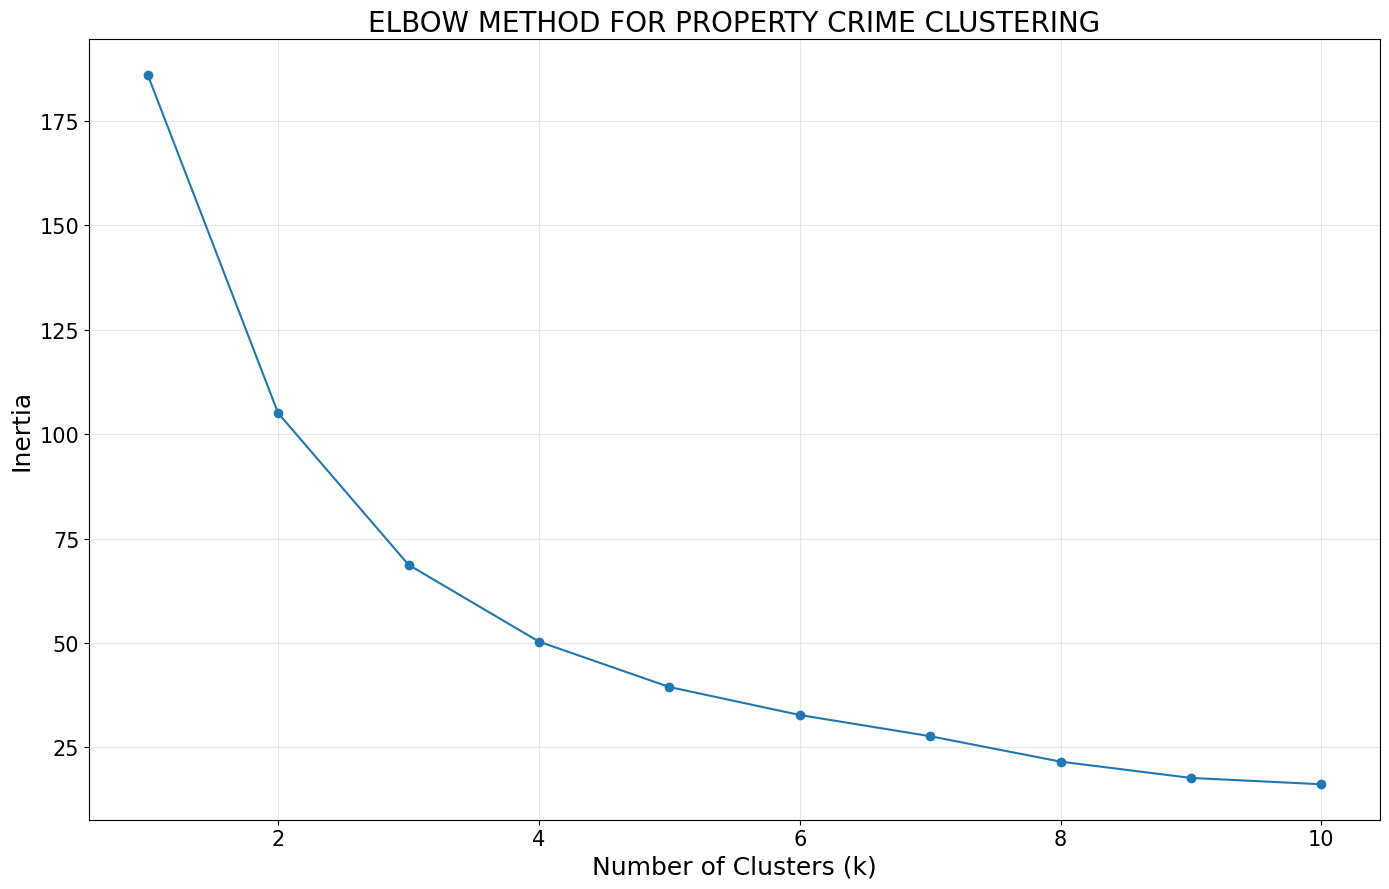


Property Crime Cluster 0
['Allegany', 'Cayuga', 'Chenango', 'Clinton', 'Columbia', 'Delaware', 'Dutchess', 'Essex', 'Franklin', 'Greene', 'Hamilton', 'Herkimer', 'Jefferson', 'Lewis', 'Livingston', 'Madison', 'Montgomery', 'Ontario', 'Orange', 'Orleans', 'Otsego', 'Putnam', 'Rockland', 'Saratoga', 'Schoharie', 'Schuyler', 'Seneca', 'St Lawrence', 'Steuben', 'Tioga', 'Ulster', 'Washington', 'Wayne', 'Wyoming', 'Yates']

Property Crime Cluster 1
['Albany', 'Erie', 'Monroe', 'Niagara', 'Onondaga', 'Schenectady']

Property Crime Cluster 2
['Bronx', 'Kings', 'Nassau', 'Queens', 'Richmond', 'Westchester']

Property Crime Cluster 3
['Broome', 'Cattaraugus', 'Chautauqua', 'Chemung', 'Cortland', 'Fulton', 'Genesee', 'New York', 'Oneida', 'Oswego', 'Rensselaer', 'Suffolk', 'Sullivan', 'Tompkins', 'Warren']

Property Crime Cluster Summary
                  Burglary_Rate  Larceny_Rate  Motor_Vehicle_Theft_Rate
Property_Cluster                                                       
0              

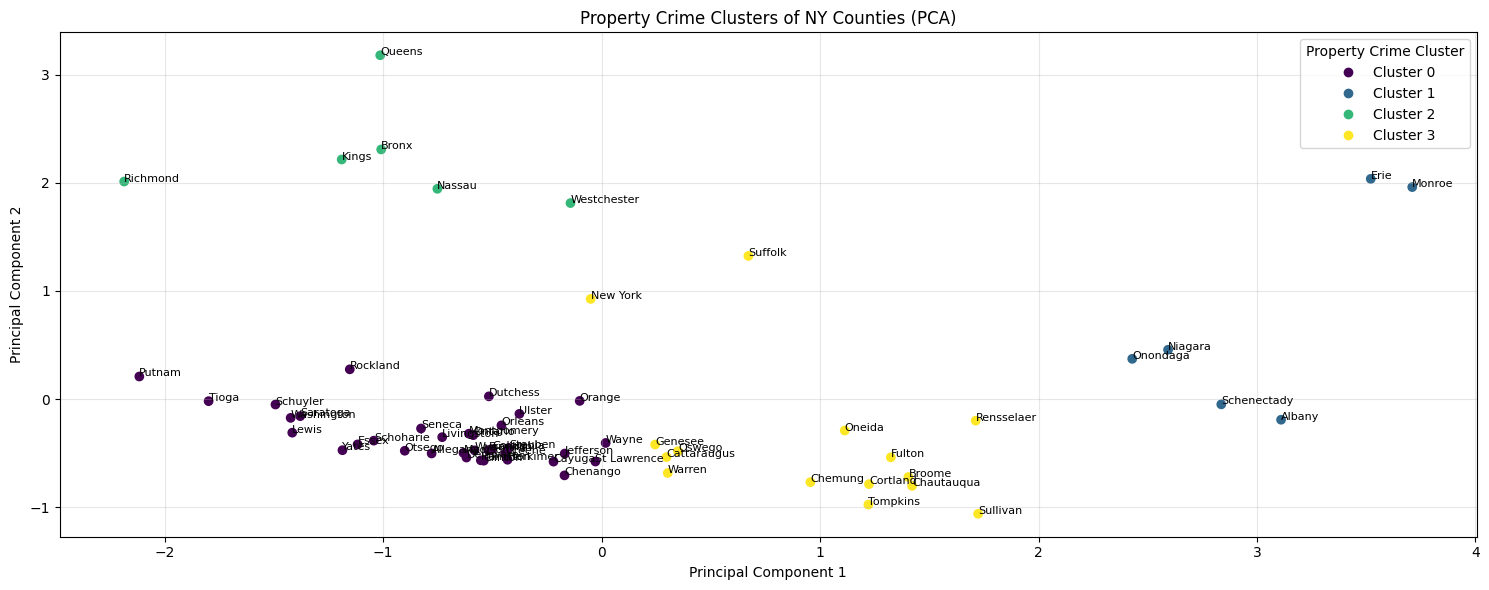

In [74]:
df = pd.read_csv("crime_with_population_rates.csv")
property_df = (
    df.groupby("County", as_index=False)[
        ["Burglary_Rate", "Larceny_Rate", "Motor_Vehicle_Theft_Rate"]
    ]
    .mean()
)
property_df = property_df.dropna()
counties = property_df["County"]
X_property = property_df.drop("County", axis=1)

scaler = StandardScaler()
X_property_scaled = scaler.fit_transform(X_property)

# Elbow Method

inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_property_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(14, 9))
plt.plot(range(1, 11), inertia, marker="o")
plt.title("ELBOW METHOD FOR PROPERTY CRIME CLUSTERING", fontsize = 20)
plt.xlabel("Number of Clusters (k)", fontsize = 18)
plt.ylabel("Inertia", fontsize = 18)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
property_df["Property_Cluster"] = kmeans.fit_predict(X_property_scaled)


for cluster in sorted(property_df["Property_Cluster"].unique()):
    print(f"\nProperty Crime Cluster {cluster}")
    print(property_df[property_df["Property_Cluster"] == cluster]["County"].tolist())


# Cluster Summary

property_summary = (
    property_df.groupby("Property_Cluster")[
        ["Burglary_Rate", "Larceny_Rate", "Motor_Vehicle_Theft_Rate"]
    ]
    .mean()
    .round(2)
)

print("\nProperty Crime Cluster Summary")
print(property_summary)


# PCA for Visualization

pca = PCA(n_components=2)
property_pca = pca.fit_transform(X_property_scaled)

property_df["PC1"] = property_pca[:, 0]
property_df["PC2"] = property_pca[:, 1]

plt.figure(figsize=(15, 6))
scatter = plt.scatter(
    property_df["PC1"],
    property_df["PC2"],
    c=property_df["Property_Cluster"]
)

for _, row in property_df.iterrows():
    plt.text(row["PC1"], row["PC2"], row["County"], fontsize=8)

handles, _ = scatter.legend_elements()
labels = [f"Cluster {i}" for i in sorted(property_df["Property_Cluster"].unique())]
plt.legend(handles, labels, title="Property Crime Cluster")


plt.title("Property Crime Clusters of NY Counties (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [75]:
# PCA for Visualization
pca = PCA(n_components=2)
property_pca = pca.fit_transform(X_property_scaled)

property_df["PC1"] = property_pca[:, 0]
property_df["PC2"] = property_pca[:, 1]

# Explained variance
print("Explained variance ratio (Property Crime PCA):")
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

Explained variance ratio (Property Crime PCA):
PC1: 0.5956
PC2: 0.293
Total explained variance: 0.8886


In [76]:
pca = PCA(n_components=2)
property_pca = pca.fit_transform(X_property_scaled)
# PCA loadings for property crime
loadings_property = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X_property.columns
)

print("Property Crime PCA Loadings:")
print(loadings_property.round(4))

Property Crime PCA Loadings:
                             PC1     PC2
Burglary_Rate             0.6479 -0.3204
Larceny_Rate              0.6655 -0.2032
Motor_Vehicle_Theft_Rate  0.3705  0.9252


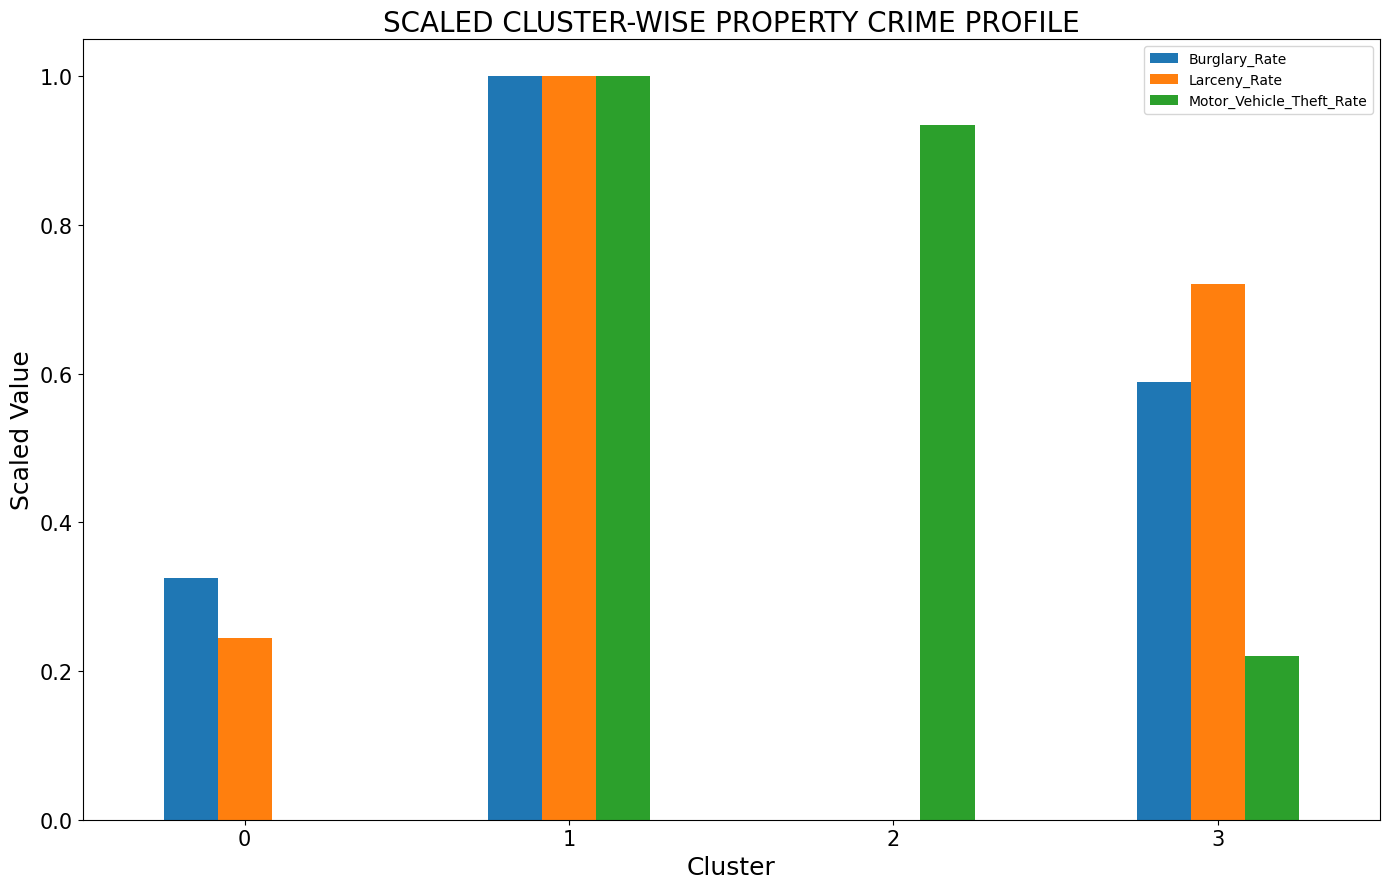

In [77]:
# Cluster-wise mean profile using original rate values
df = pd.read_csv("crime_with_population_rates.csv")
property_df = (
    df.groupby("County", as_index=False)[
        ["Burglary_Rate", "Larceny_Rate", "Motor_Vehicle_Theft_Rate"]
    ]
    .mean()
    .dropna()
)

X_property = property_df.drop("County", axis=1)
scaler = StandardScaler()
X_property_scaled = scaler.fit_transform(X_property)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
property_df["Property_Cluster"] = kmeans.fit_predict(X_property_scaled)
property_profile = (
    property_df.groupby("Property_Cluster")[
        ["Burglary_Rate", "Larceny_Rate", "Motor_Vehicle_Theft_Rate"]
    ]
    .mean()
)
minmax = MinMaxScaler()
property_profile_scaled = pd.DataFrame(
    minmax.fit_transform(property_profile),
    columns=property_profile.columns,
    index=property_profile.index
)

property_profile_scaled.plot(kind="bar", figsize=(14, 9))
plt.title("SCALED CLUSTER-WISE PROPERTY CRIME PROFILE", fontsize = 20)
plt.xlabel("Cluster", fontsize = 18)
plt.ylabel("Scaled Value", fontsize = 18)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

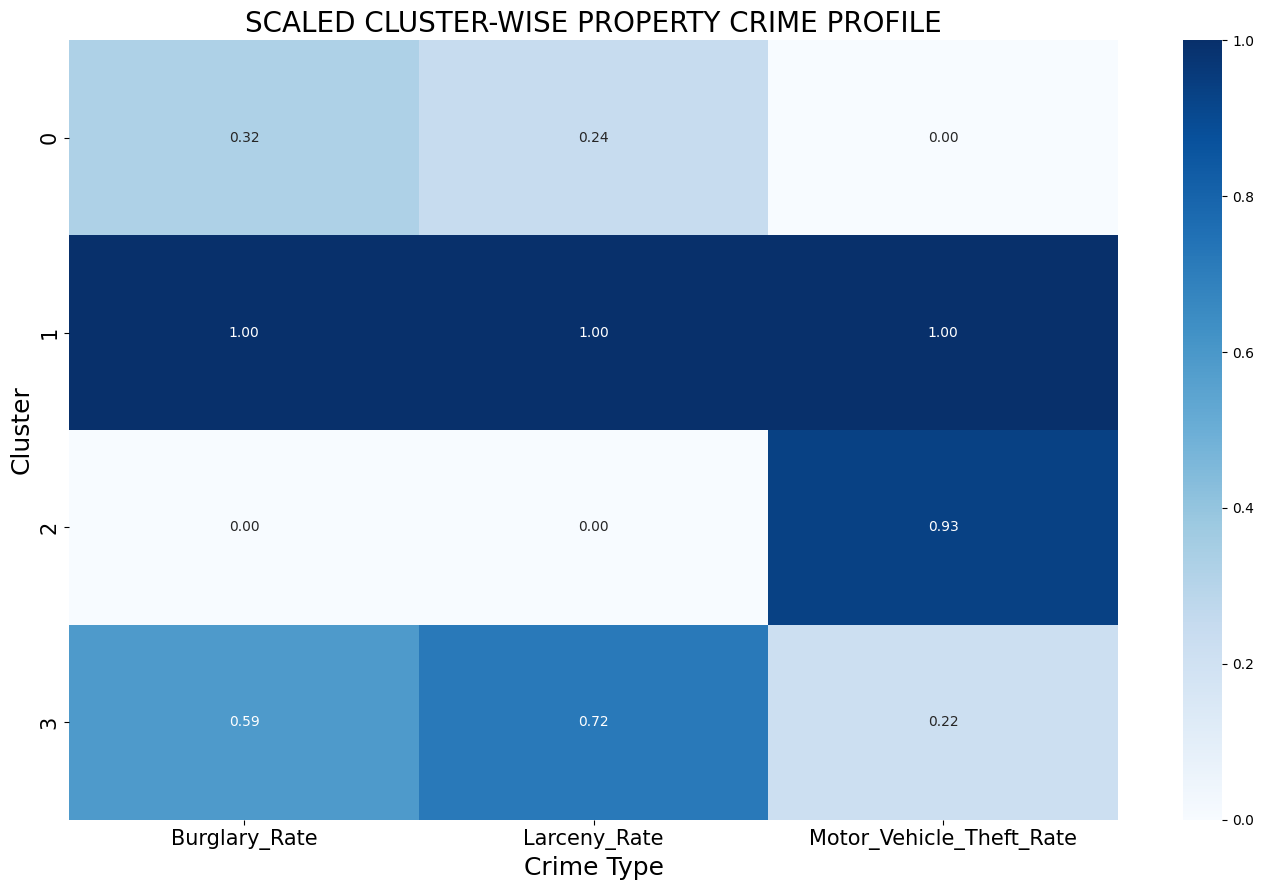

In [ ]:
# Heatmap of scaled cluster-wise property crime profiles

plt.figure(figsize=(14, 9))
sns.heatmap(property_profile_scaled, annot=True, cmap="Blues", fmt=".2f")
plt.title("SCALED CLUSTER-WISE PROPERTY CRIME PROFILE", fontsize = 20)
plt.xlabel("Crime Type", fontsize = 18)
plt.ylabel("Cluster", fontsize = 18)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.tight_layout()
plt.show()

Logistic Regression

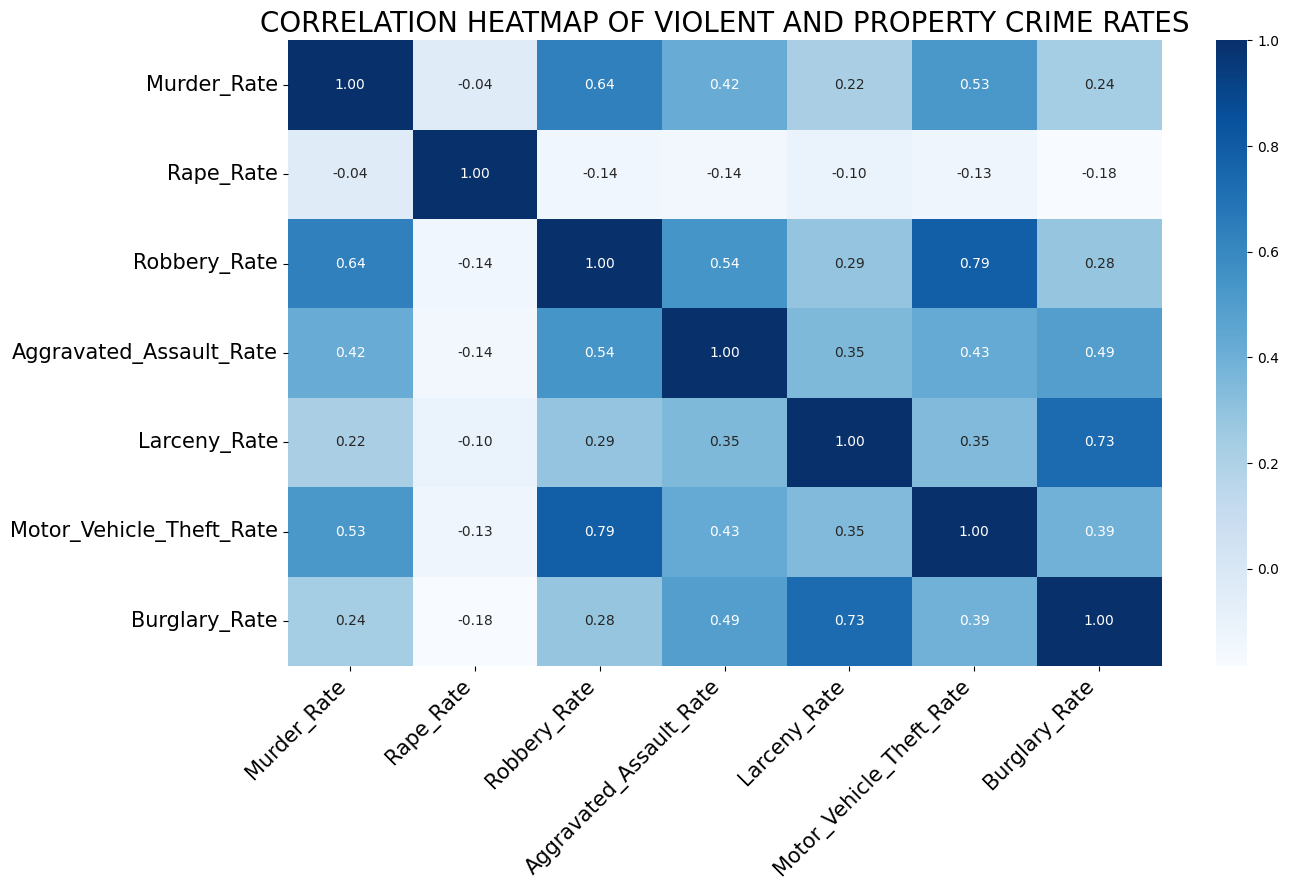

In [79]:
# Correlation heatmap of violent and property crime rates
df = pd.read_csv("crime_with_population_rates.csv")
df.columns = df.columns.str.strip()
rate_df = df[[
    "Murder_Rate",
    "Rape_Rate",
    "Robbery_Rate",
    "Aggravated_Assault_Rate",
    "Larceny_Rate",
    "Motor_Vehicle_Theft_Rate",
    "Burglary_Rate"
]]

plt.figure(figsize=(14, 9))
sns.heatmap(rate_df.corr(), annot=True, cmap="Blues", fmt=".2f")

plt.title("CORRELATION HEATMAP OF VIOLENT AND PROPERTY CRIME RATES", fontsize=20)
plt.xticks(fontsize=15, rotation=45, ha="right")
plt.yticks(fontsize=15, rotation=0)

plt.tight_layout()
plt.show()

In [80]:
# Variance Inflation Factor
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[[
    
    "Rape_Rate",
    "Robbery_Rate",
    "Aggravated_Assault_Rate",'Larceny_Rate','Motor_Vehicle_Theft_Rate','Burglary_Rate'
    
]].copy()

X = X.dropna()
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                    Feature        VIF
0                 Rape_Rate   2.071465
1              Robbery_Rate   4.323521
2   Aggravated_Assault_Rate   5.623371
3              Larceny_Rate  10.110384
4  Motor_Vehicle_Theft_Rate   4.568313
5             Burglary_Rate  10.188347


In [ ]:
#-Variance Inflation Factor after removng Burglary_Rate
X = df[[
    
    "Rape_Rate",
    "Robbery_Rate",
    "Aggravated_Assault_Rate",'Larceny_Rate','Motor_Vehicle_Theft_Rate'
]].copy()
X = X.dropna()
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                    Feature       VIF
0                 Rape_Rate  2.004189
1              Robbery_Rate  4.080184
2   Aggravated_Assault_Rate  4.779612
3              Larceny_Rate  4.701751
4  Motor_Vehicle_Theft_Rate  4.304041


Best Parameters: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__solver': 'lbfgs'}
Best CV Score: 0.5981596998618

Test Accuracy: 0.6405529953917051
Test Precision: 0.6697508081605935
Test Recall: 0.6405529953917051
Test F1-score: 0.6388612438062203

Classification Report:

              precision    recall  f1-score   support

        High       0.82      0.52      0.64       145
         Low       0.59      0.78      0.67       145
      Medium       0.60      0.62      0.61       144

    accuracy                           0.64       434
   macro avg       0.67      0.64      0.64       434
weighted avg       0.67      0.64      0.64       434


Confusion Matrix:

[[ 75  36  34]
 [  5 113  27]
 [ 11  43  90]]


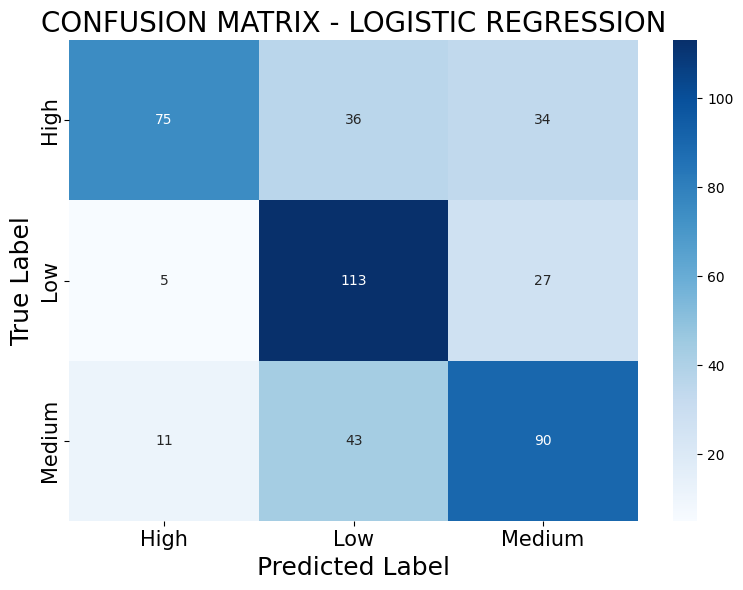


Feature Importance:

         Feature  Importance
29        Nassau    1.455902
48        Seneca    1.121041
40        Queens    1.119308
59   Westchester    1.056277
15         Essex    1.033028
51       Suffolk    1.026314
61         Yates    1.000294
24         Lewis    0.992047
46     Schoharie    0.967746
42      Richmond    0.907552
47      Schuyler    0.896324
7        Chemung    0.855412
20      Hamilton    0.810116
64  Robbery_Rate    0.771204
32        Oneida    0.760833


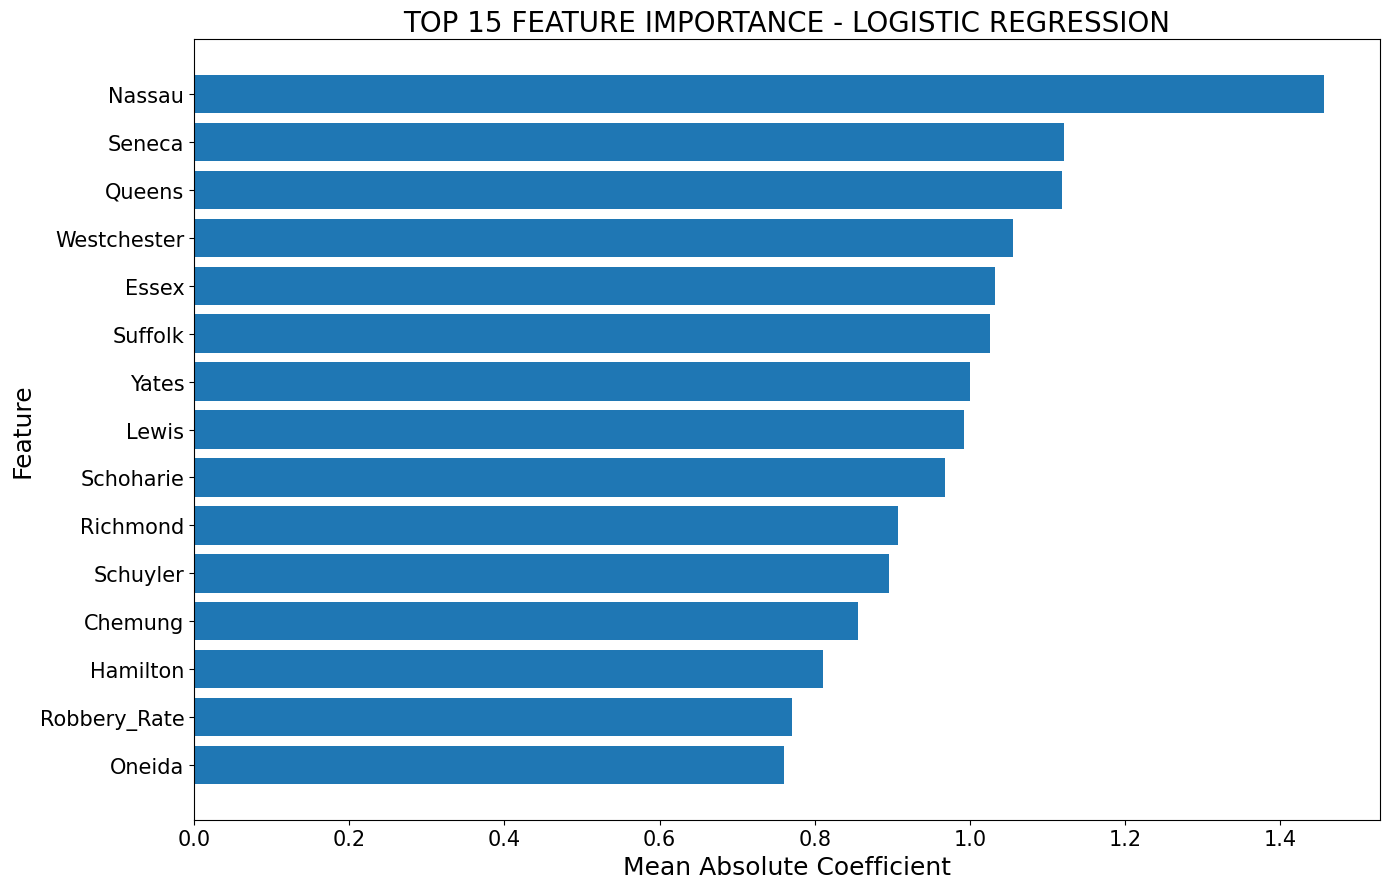

In [81]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

df = pd.read_csv("crime_with_population_rates.csv")
df.columns = df.columns.str.strip()


data = df[[
    "County",
    "Year",
    "Murder_Rate",
    "Rape_Rate",
    "Robbery_Rate",
    "Aggravated_Assault_Rate",
    "Larceny_Rate",
    "Motor_Vehicle_Theft_Rate"
]].copy()

data = data.dropna()

data["Murder_Level"] = pd.qcut(
    data["Murder_Rate"],
    q=3,
    labels=["Low", "Medium", "High"]
)


X = data[[
    "County",
    "Year",
    "Rape_Rate",
    "Robbery_Rate",
    "Aggravated_Assault_Rate",
    "Larceny_Rate",
    "Motor_Vehicle_Theft_Rate"
]]

y = data["Murder_Level"]


# RANDOM TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


categorical_features = ["County"]
numeric_features = [
    "Year",
    "Rape_Rate",
    "Robbery_Rate",
    "Aggravated_Assault_Rate",
    "Larceny_Rate",
    "Motor_Vehicle_Theft_Rate"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)


# PIPELINE

pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])


# GRID SEARCH

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__solver": ["lbfgs", "saga"],
    "classifier__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

# -----------------------------
# TRAIN TUNED MODEL
# -----------------------------
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

# -----------------------------
# BEST MODEL PREDICTION
# -----------------------------
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

# -----------------------------
# EVALUATION
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("\nTest Accuracy:", accuracy)
print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test F1-score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

# -----------------------------
# CONFUSION MATRIX
# -----------------------------
labels = ["High", "Low", "Medium"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("\nConfusion Matrix:\n")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("CONFUSION MATRIX - LOGISTIC REGRESSION", fontsize=20)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.tight_layout()
plt.show()

# -----------------------------
# FEATURE IMPORTANCE
# -----------------------------
preprocessor_fitted = best_model.named_steps["preprocessor"]
classifier_fitted = best_model.named_steps["classifier"]

feature_names = preprocessor_fitted.get_feature_names_out()
coef = classifier_fitted.coef_

# Mean absolute coefficient across classes
importance = abs(coef).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Clean feature names
feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__County_", "", regex=False)
)

feature_importance = feature_importance.sort_values("Importance", ascending=False)

print("\nFeature Importance:\n")
print(feature_importance.head(15))

top_features = feature_importance.head(15).sort_values("Importance", ascending=True)

plt.figure(figsize=(14, 9))
plt.barh(top_features["Feature"], top_features["Importance"])

plt.title("TOP 15 FEATURE IMPORTANCE - LOGISTIC REGRESSION", fontsize=20)
plt.xlabel("Mean Absolute Coefficient", fontsize=18)
plt.ylabel("Feature", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.tight_layout()
plt.show()

Decision Tree

Best Parameters: {'classifier__criterion': 'entropy', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5}
Best CV Score: 0.5037163624554252

Test Accuracy: 0.5253456221198156
Test Precision: 0.5245007680491551
Test Recall: 0.5253456221198156
Test F1-score: 0.5246111944311613

Classification Report:

              precision    recall  f1-score   support

        High       0.54      0.56      0.55       145
         Low       0.53      0.55      0.54       145
      Medium       0.50      0.47      0.48       144

    accuracy                           0.53       434
   macro avg       0.52      0.53      0.52       434
weighted avg       0.52      0.53      0.52       434


Confusion Matrix:

[[81 31 33]
 [31 80 34]
 [38 39 67]]


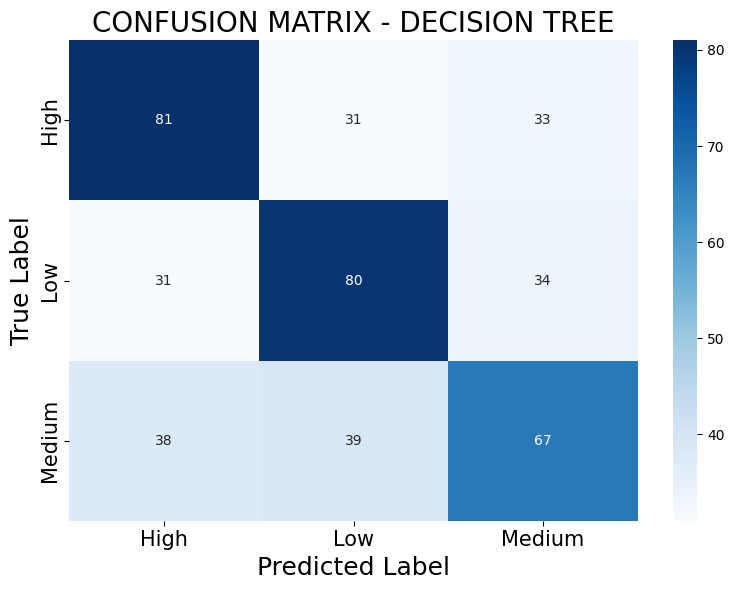


Feature Importance:

                     Feature  Importance
64              Robbery_Rate    0.320475
65   Aggravated_Assault_Rate    0.144959
63                 Rape_Rate    0.133041
67  Motor_Vehicle_Theft_Rate    0.118537
66              Larceny_Rate    0.112683
62                      Year    0.063697
48                    Seneca    0.008810
32                    Oneida    0.007001
9                    Clinton    0.006680
52                  Sullivan    0.005721
55                    Ulster    0.005207
15                     Essex    0.004979
50                   Steuben    0.004393
33                  Onondaga    0.004321
7                    Chemung    0.004210


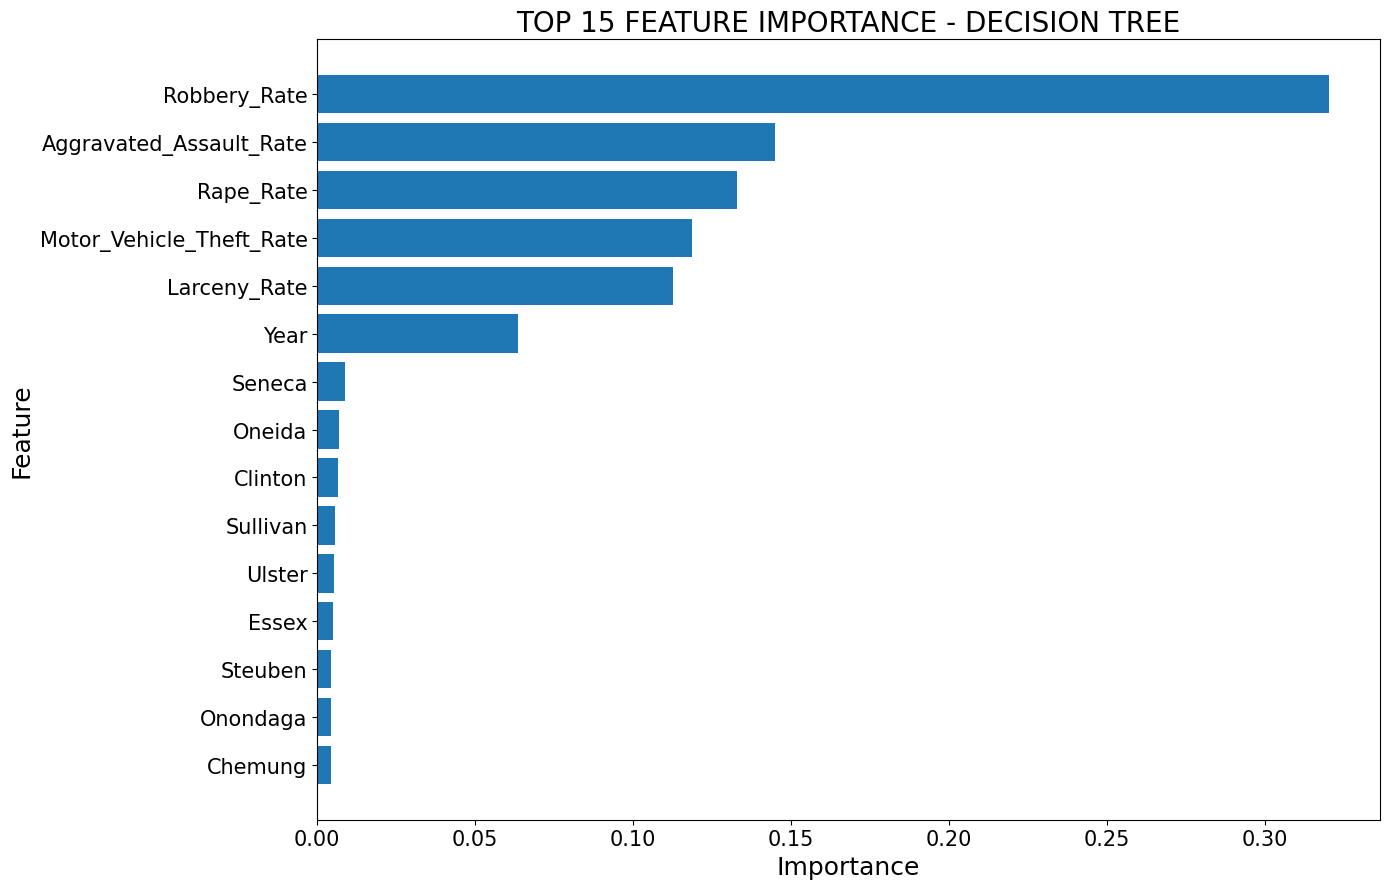

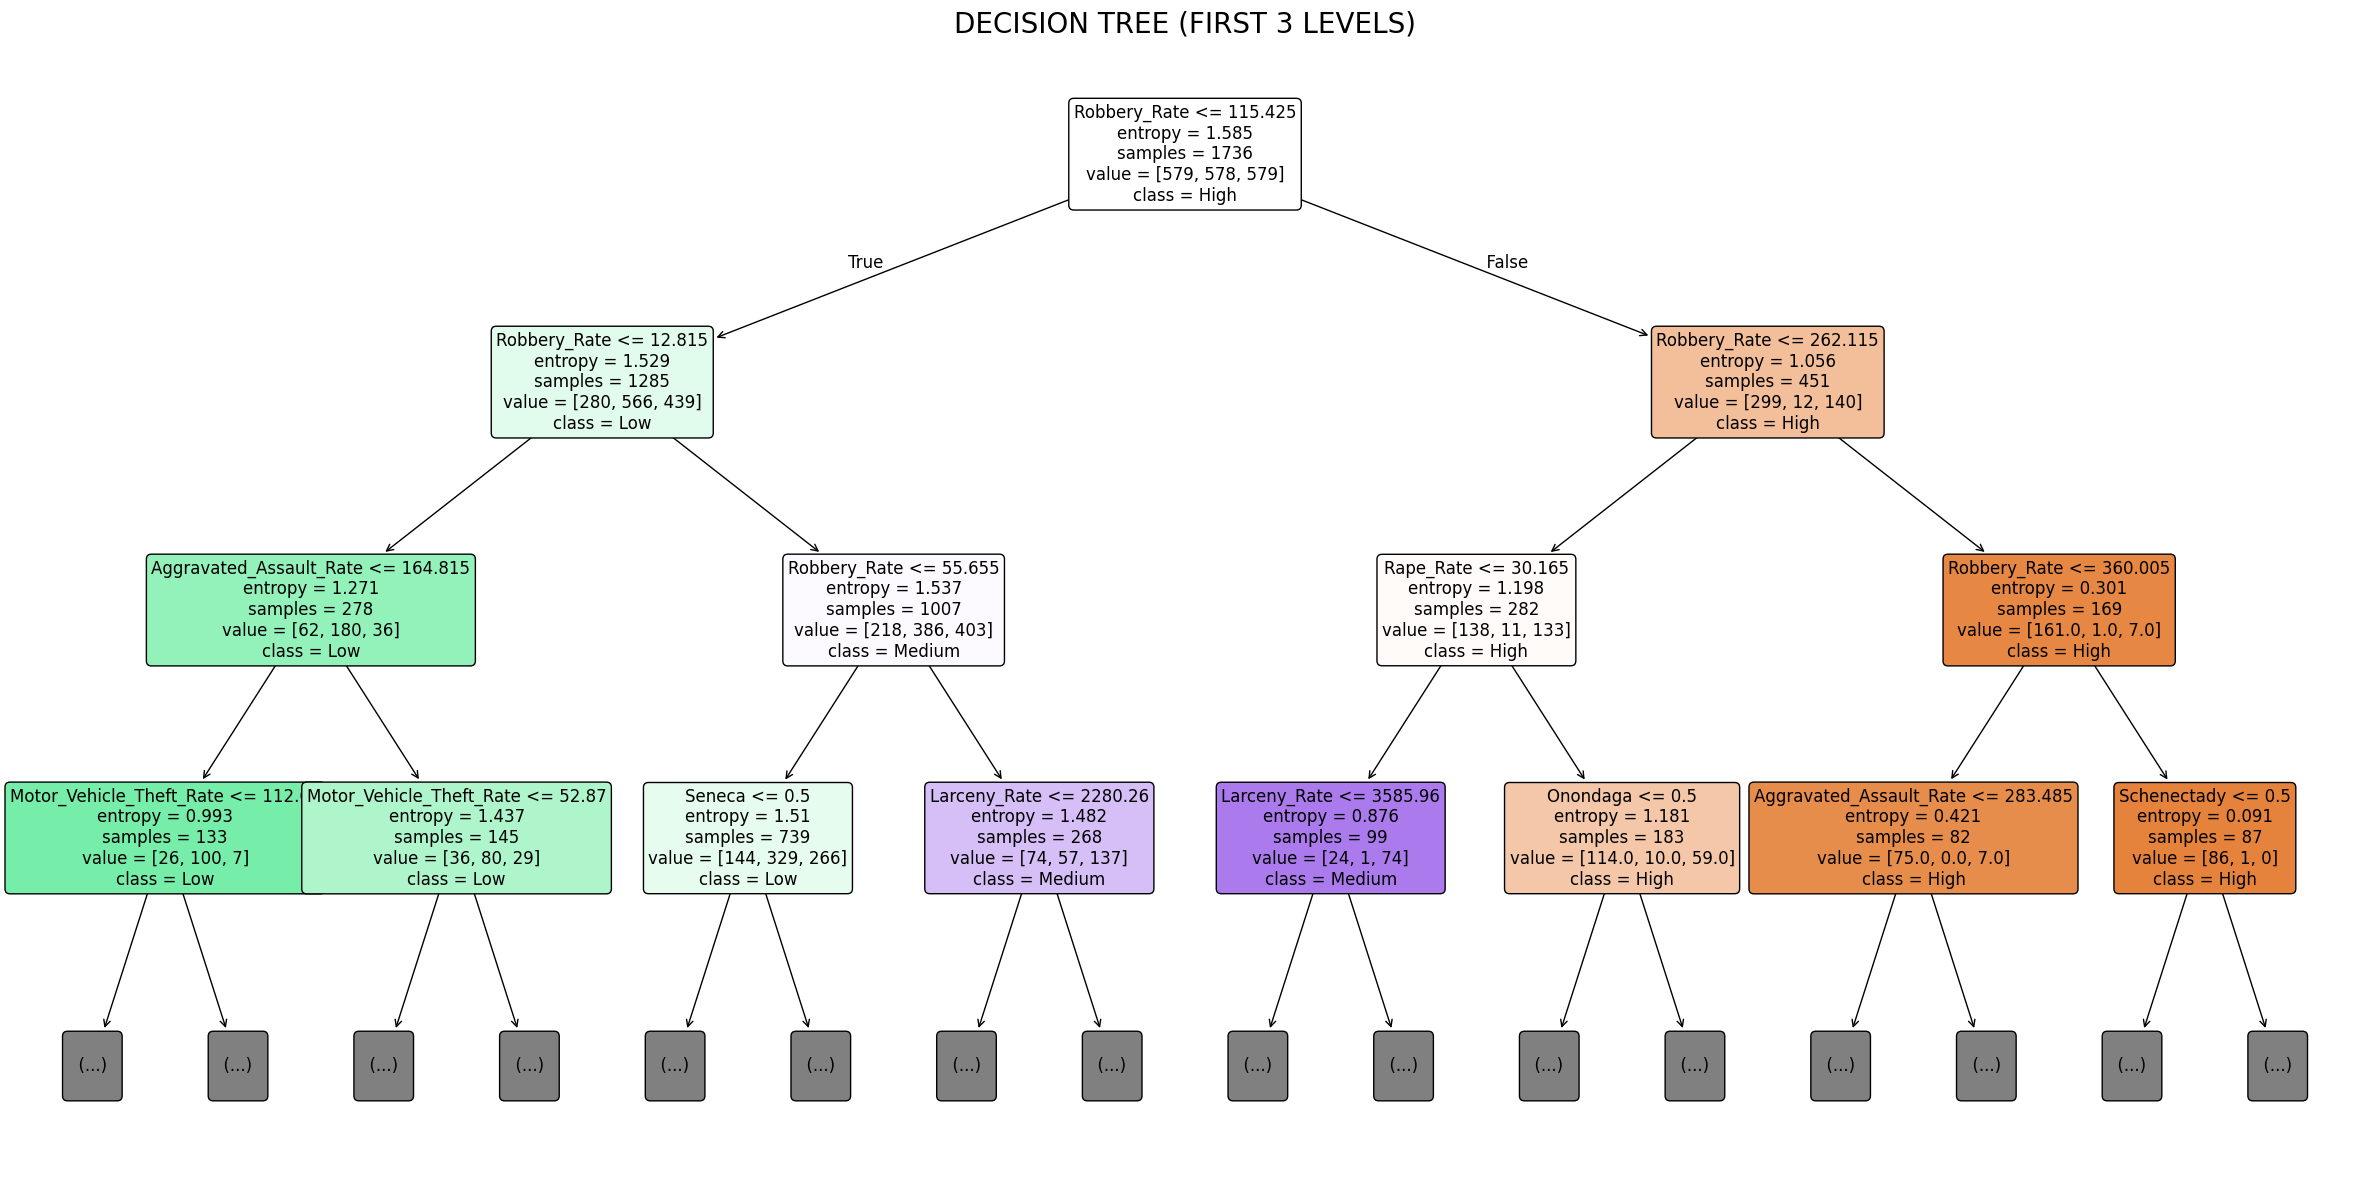

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

df = pd.read_csv("crime_with_population_rates.csv")
df.columns = df.columns.str.strip()
data = df[[
    "County",
    "Year",
    "Murder_Rate",
    "Rape_Rate",
    "Robbery_Rate",
    "Aggravated_Assault_Rate",
    "Larceny_Rate",
    "Motor_Vehicle_Theft_Rate"
]].copy()

data = data.dropna()
data["Murder_Level"] = pd.qcut(
    data["Murder_Rate"],
    q=3,
    labels=["Low", "Medium", "High"]
)


X = data[[
    "County",
    "Year",
    "Rape_Rate",
    "Robbery_Rate",
    "Aggravated_Assault_Rate",
    "Larceny_Rate",
    "Motor_Vehicle_Theft_Rate"
]]

y = data["Murder_Level"]


# RANDOM TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


categorical_features = ["County"]
numeric_features = [
    "Year",
    "Rape_Rate",
    "Robbery_Rate",
    "Aggravated_Assault_Rate",
    "Larceny_Rate",
    "Motor_Vehicle_Theft_Rate"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)
# PIPELINE
pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])
# GRID SEARCH
param_grid = {
    "classifier__criterion": ["gini", "entropy"],
    #"classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)
# TRAIN TUNED MODEL
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
# BEST MODEL PREDICTION
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("\nTest Accuracy:", accuracy)
print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test F1-score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))


labels = ["High", "Low", "Medium"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("\nConfusion Matrix:\n")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("CONFUSION MATRIX - DECISION TREE", fontsize=20)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.tight_layout()
plt.show()


preprocessor_fitted = best_model.named_steps["preprocessor"]
classifier_fitted = best_model.named_steps["classifier"]

feature_names = preprocessor_fitted.get_feature_names_out()
importance = classifier_fitted.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__County_", "", regex=False)
)

feature_importance = feature_importance.sort_values("Importance", ascending=False)

print("\nFeature Importance:\n")
print(feature_importance.head(15))

top_features = feature_importance.head(15).sort_values("Importance", ascending=True)

plt.figure(figsize=(14, 9))
plt.barh(top_features["Feature"], top_features["Importance"])

plt.title("TOP 15 FEATURE IMPORTANCE - DECISION TREE", fontsize=20)
plt.xlabel("Importance", fontsize=18)
plt.ylabel("Feature", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.tight_layout()
plt.show()


clean_feature_names = (
    pd.Series(feature_names)
    .str.replace("num__", "", regex=False)
    .str.replace("cat__County_", "", regex=False)
    .tolist()
)

plt.figure(figsize=(24, 12))
plot_tree(
    classifier_fitted,
    feature_names=clean_feature_names,
    class_names=[str(c) for c in classifier_fitted.classes_],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=12
)

plt.title("DECISION TREE (FIRST 3 LEVELS)", fontsize=20)
plt.tight_layout()
plt.show()

Random Forest

Best Parameters: {'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV Score: 0.584119147180931

Test Accuracy: 0.6267281105990783
Test Precision: 0.6473307158791031
Test Recall: 0.6267281105990783
Test F1-score: 0.6248511843487367

Classification Report:

              precision    recall  f1-score   support

        High       0.78      0.53      0.63       145
         Low       0.58      0.77      0.66       145
      Medium       0.58      0.58      0.58       144

    accuracy                           0.63       434
   macro avg       0.65      0.63      0.62       434
weighted avg       0.65      0.63      0.62       434


Confusion Matrix:

[[ 77  37  31]
 [  4 112  29]
 [ 18  43  83]]


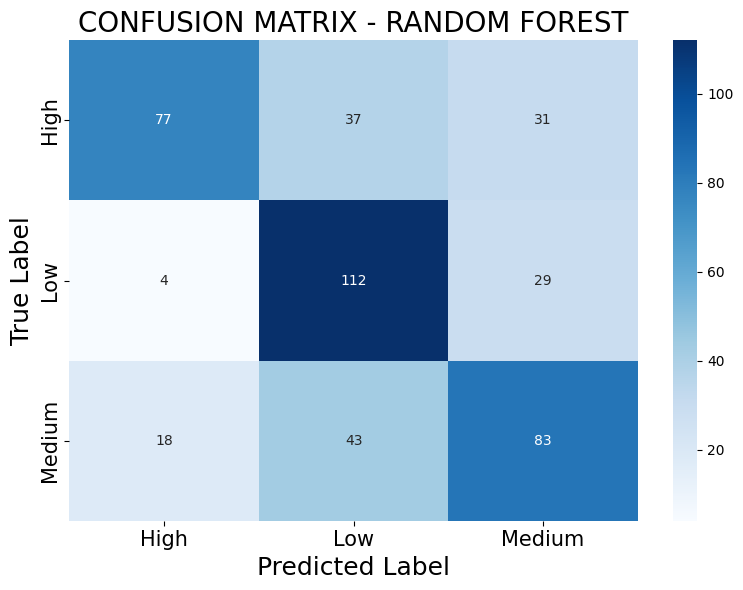


Feature Importance:

                     Feature  Importance
64              Robbery_Rate    0.206556
67  Motor_Vehicle_Theft_Rate    0.143076
65   Aggravated_Assault_Rate    0.126523
66              Larceny_Rate    0.100602
63                 Rape_Rate    0.081995
62                      Year    0.077100
32                    Oneida    0.009891
33                  Onondaga    0.009155
2                      Bronx    0.009103
27                    Monroe    0.008516
14                      Erie    0.008100
52                  Sullivan    0.007968
29                    Nassau    0.007698
48                    Seneca    0.007660
20                  Hamilton    0.007377


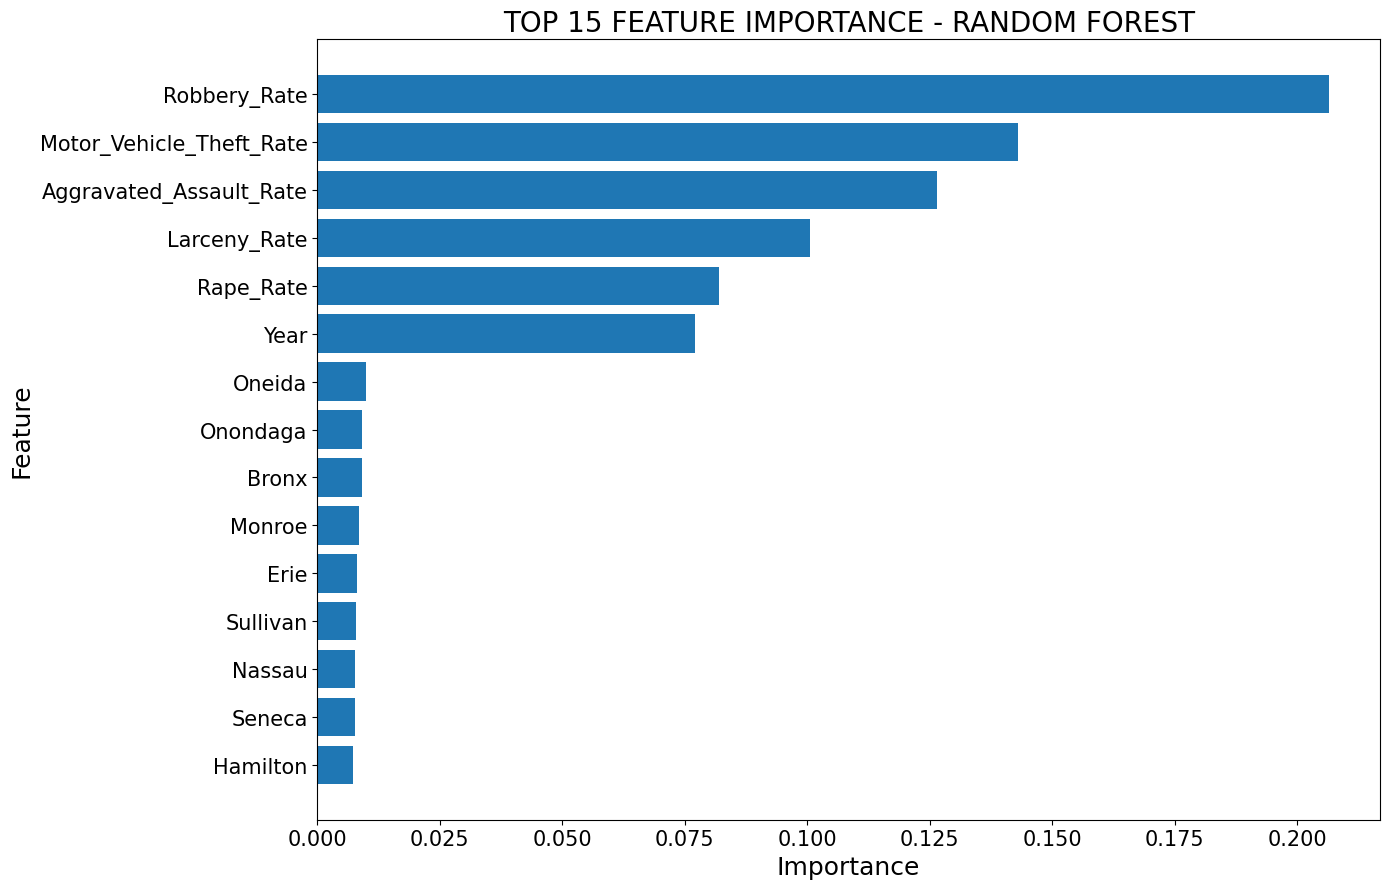

In [83]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

df = pd.read_csv("crime_with_population_rates.csv")
df.columns = df.columns.str.strip()
data = df[[
    "County",
    "Year",
    "Murder_Rate",
    "Rape_Rate",
    "Robbery_Rate",
    "Aggravated_Assault_Rate",
    "Larceny_Rate",
    "Motor_Vehicle_Theft_Rate"
]].copy()

data = data.dropna()
data["Murder_Level"] = pd.qcut(
    data["Murder_Rate"],
    q=3,
    labels=["Low", "Medium", "High"]
)
X = data[[
    "County",
    "Year",
    "Rape_Rate",
    "Robbery_Rate",
    "Aggravated_Assault_Rate",
    "Larceny_Rate",
    "Motor_Vehicle_Theft_Rate"
]]

y = data["Murder_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

categorical_features = ["County"]
numeric_features = [
    "Year",
    "Rape_Rate",
    "Robbery_Rate",
    "Aggravated_Assault_Rate",
    "Larceny_Rate",
    "Motor_Vehicle_Theft_Rate"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# PIPELINE
pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])
# GRID SEARCH
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    #"classifier__max_depth": [5, 10, 15, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

# TRAIN TUNED MODEL
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
# BEST MODEL PREDICTION
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("\nTest Accuracy:", accuracy)
print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test F1-score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

labels = ["High", "Low", "Medium"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

print("\nConfusion Matrix:\n")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("CONFUSION MATRIX - RANDOM FOREST", fontsize=20)
plt.xlabel("Predicted Label", fontsize=18)
plt.ylabel("True Label", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.tight_layout()
plt.show()

preprocessor_fitted = best_model.named_steps["preprocessor"]
classifier_fitted = best_model.named_steps["classifier"]

feature_names = preprocessor_fitted.get_feature_names_out()
importance = classifier_fitted.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__County_", "", regex=False)
)

feature_importance = feature_importance.sort_values("Importance", ascending=False)

print("\nFeature Importance:\n")
print(feature_importance.head(15))

top_features = feature_importance.head(15).sort_values("Importance", ascending=True)

plt.figure(figsize=(14, 9))
plt.barh(top_features["Feature"], top_features["Importance"])

plt.title("TOP 15 FEATURE IMPORTANCE - RANDOM FOREST", fontsize=20)
plt.xlabel("Importance", fontsize=18)
plt.ylabel("Feature", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.tight_layout()
plt.show()